# Лекция 2. Анализ бинарных изображений. Базовые операции математической морфологии: дилатация и эрозия

In [1]:
# импорт библиотек

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, measure
from scipy import ndimage

plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Бинарные изображения

Бинарное изображение – это изображение, каждый пиксель которого может принимать только два значения: **0** (фон) и **1** (объект) (или 0 и 255 в OpenCV). Т.е. бинарные изображения содержат пиксели только с двумя значениями интенсивности – максимальным и минимальным.


**Применение:**
- Идентификация объектов с заданным силуэтом (например, деталей, движущихся по конвейеру).
- Распознавание символов и текста (например, при обработке документов, интерпретации дорожных знаков).
- Определение ориентации объектов.
- Применение в качестве маски, например, в задачах сегментации, в том числе и нейросетевой.


**Пример:** создадим простые бинарные фигуры – прямоугольник с вырезом и наклонный эллипс.

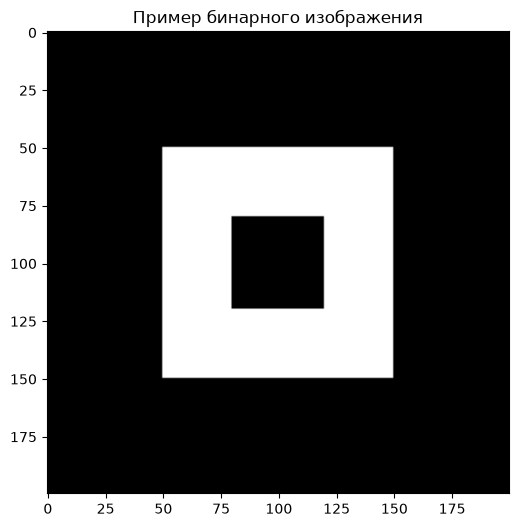

In [2]:
# Создаём бинарное изображение 200x200
img1 = np.zeros((200,200), dtype=np.uint8)
img1[50:150, 50:150] = 1          # квадрат
img1[80:120, 80:120] = 0          # вырез

plt.imshow(img1, cmap='gray')
plt.title('Пример бинарного изображения')
#plt.axis('off')
plt.show()

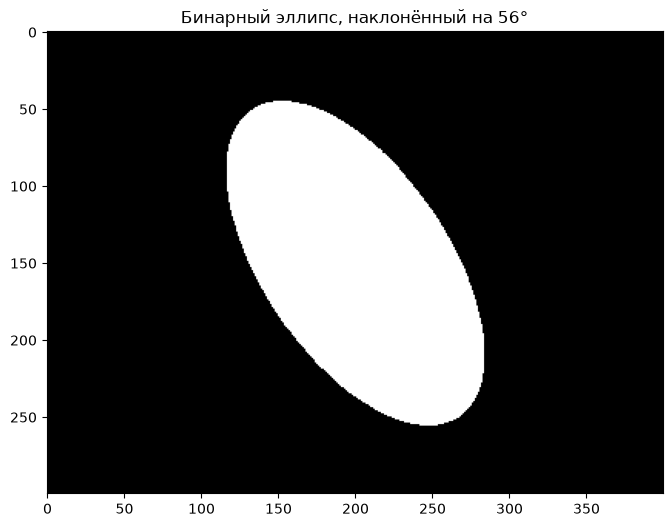

In [3]:
# Создаём бинарное изображение с эллипсом
img2 = np.zeros((300, 400), dtype=np.uint8)
center = (200, 150)          # центр эллипса
axes = (120, 60)             # большая и малая полуоси
angle_ellipse = 56           # угол наклона в градусах

# Рисуем залитый эллипс (значение 1 – белый)
cv2.ellipse(img2, center, axes, angle_ellipse, 0, 360, 1, thickness=-1)

plt.imshow(img2, cmap='gray')
plt.title('Бинарный эллипс, наклонённый на 56°')
plt.show()

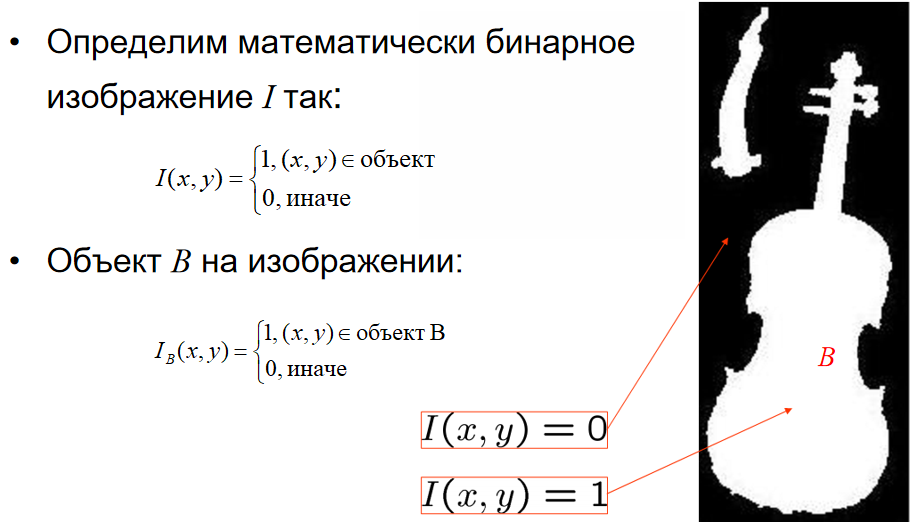

## 2. Моменты бинарных изображений


Моменты – это числовые характеристики формы объекта, инвариантные к некоторым преобразованиям.

### 2.1. Нулевой момент – площадь

$$ M_{00} = \sum_{x,y} I(x,y) $$
Для бинарного изображения это просто количество пикселей объекта.

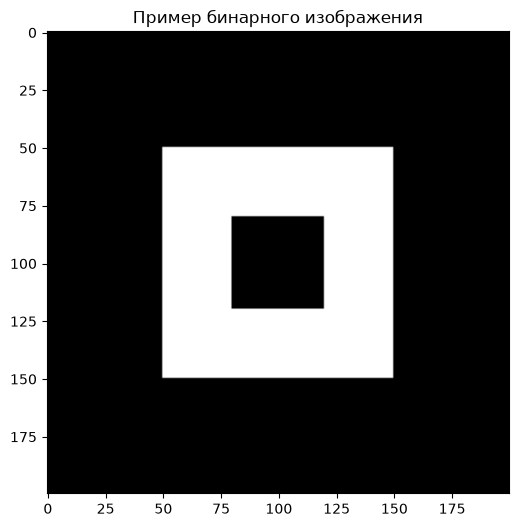

Площадь объекта (нулевой момент): 8400 пикселей


In [4]:
plt.imshow(img1, cmap='gray')
plt.title('Пример бинарного изображения')
#plt.axis('off')
plt.show()
area1 = np.sum(img1)
print(f"Площадь объекта (нулевой момент): {area1} пикселей")

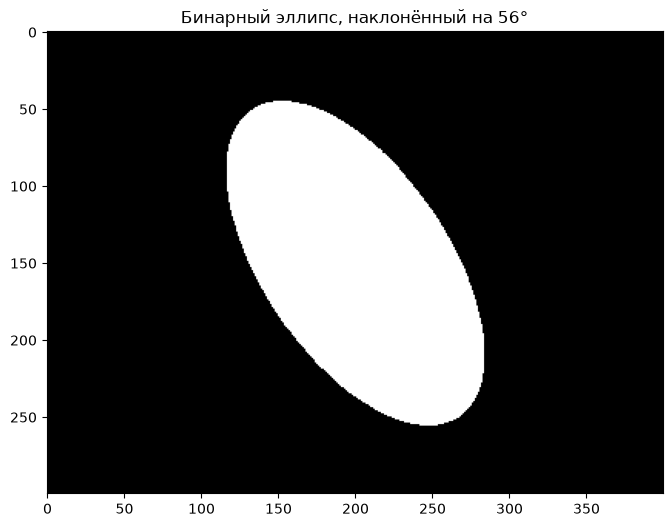

Площадь объекта (нулевой момент): 22880 пикселей


In [5]:
plt.imshow(img2, cmap='gray')
plt.title('Бинарный эллипс, наклонённый на 56°')
#plt.axis('off')
plt.show()
area2 = np.sum(img2)
print(f"Площадь объекта (нулевой момент): {area2} пикселей")

### 2.2. Первые моменты и центроид



Первые моменты объекта:
$$ M_{10} = \sum_{x,y} x \cdot I(x,y), \quad M_{01} = \sum_{x,y} y \cdot I(x,y) $$




Момент первого порядка $M_{10} = \sum x \cdot I(x,y)$ (и аналогично $ M_{01} $) сам по себе **не имеет наглядной физической интерпретации**, потому что его численное значение зависит от положения объекта на изображении: чем дальше объект от начала координат, тем больше момент.

**Смысл раскрывается при совместном использовании с нулевым моментом $M_{00} $.**  
Нормализованные первые моменты дают центроид объекта. Физическая аналогия центроида – центр тяжести объекта, вычисляется как  
$$
\bar{x} = \frac{M_{10}}{M_{00}}, \quad \bar{y} = \frac{M_{01}}{M_{00}}.
$$



Таким образом, пара первых моментов, нормированная на площадь, задаёт **координаты геометрического центра объекта** (среднее арифметическое координат всех его точек). Именно центроид используют для определения положения объекта на изображении, его смещения, а также при вычислении центральных моментов (инвариантных к сдвигу).

**Простыми словами:**  
- Нулевой момент → сколько точек в объекте.  
- Первые моменты → где эти точки расположены в сумме.  
- Их отношение → где находится «средняя точка» (центроид).

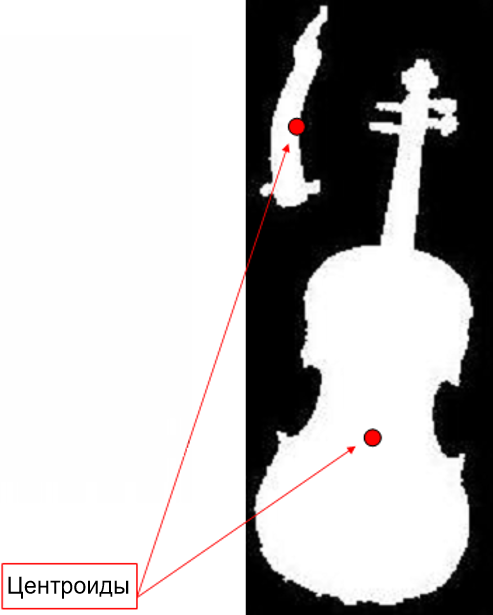

Найдем центроиды для наших модельных объектов

Центроид: (99.5, 99.5)


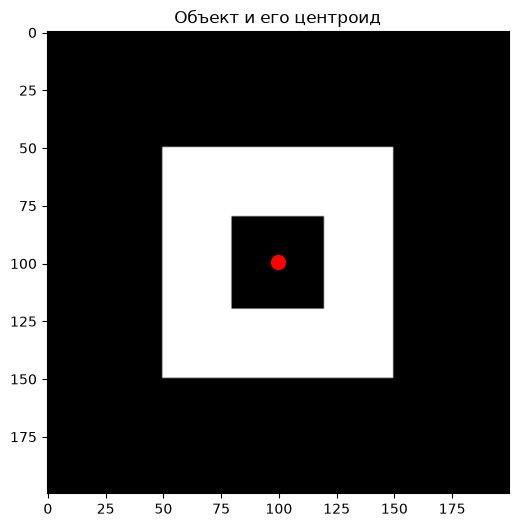

In [12]:
y1, x1 = np.where(img1 == 1)   # координаты всех белых пикселей
M10 = np.sum(x1)
M01 = np.sum(y1)
centroid_x1 = M10 / area1
centroid_y1 = M01 / area1
print(f"Центроид: ({centroid_x1:.1f}, {centroid_y1:.1f})")

# Визуализация
plt.imshow(img1, cmap='gray')
plt.plot(centroid_x1, centroid_y1, 'ro', markersize=10)
plt.title('Объект и его центроид')
plt.show()

Для эллипса

Центроид (вычисленный по моментам): (200.0, 150.0)
Заданный центр эллипса: (200, 150)


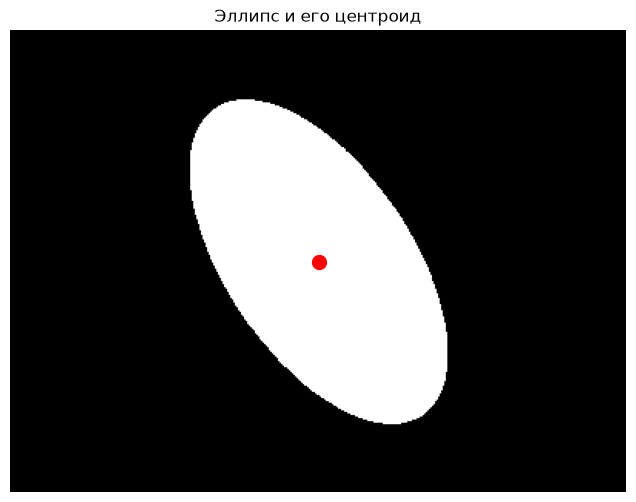

In [14]:
y2, x2 = np.where(img2 == 1)
M10 = np.sum(x2)
M01 = np.sum(y2)
centroid_x2 = M10 / area2
centroid_y2 = M01 / area2
print(f"Центроид (вычисленный по моментам): ({centroid_x2:.1f}, {centroid_y2:.1f})")
print(f"Заданный центр эллипса: ({center[0]}, {center[1]})")

# Визуализация
plt.imshow(img2, cmap='gray')
plt.plot(centroid_x2, centroid_y2, 'ro', markersize=10)
plt.title('Эллипс и его центроид')
plt.axis('off')
plt.show()

### 2.3. Вторые центральные моменты и ориентация объекта в пространстве



Центральные моменты инвариантны к сдвигу и записываются в общем виде так:
$$ \mu_{pq} = \sum_{x,y} (x - \bar{x})^p (y - \bar{y})^q I(x,y) $$

Например, центральный момент
$$ \mu_{20} = \sum_{x,y} (x - \bar{x})^2 I(x,y) ,$$
а центральный момент
$$ \mu_{11} = \sum_{x,y} (x - \bar{x}) (y - \bar{y}) I(x,y) $$

Центральные моменты инвариантны к сдвигу и связаны с матрицей инерции $U$ объекта. Матрица инерции (ковариационная матрица):
$$ U = \begin{bmatrix} \mu_{20} & \mu_{11} \\ \mu_{11} & \mu_{02} \end{bmatrix} $$

Собственные векторы $U$ задают направления максимальной и минимальной инерции.

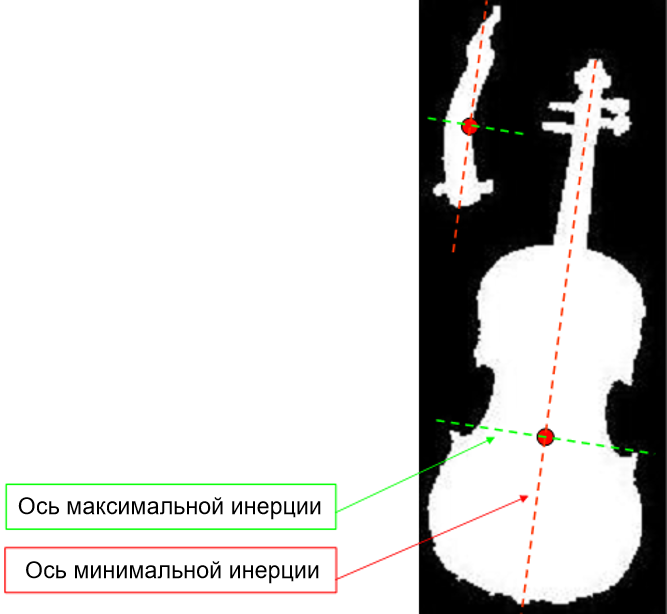

 Угол ориентации:
$$ \theta = \frac{1}{2} \arctan\left(\frac{2\mu_{11}}{\mu_{20} - \mu_{02}}\right) $$

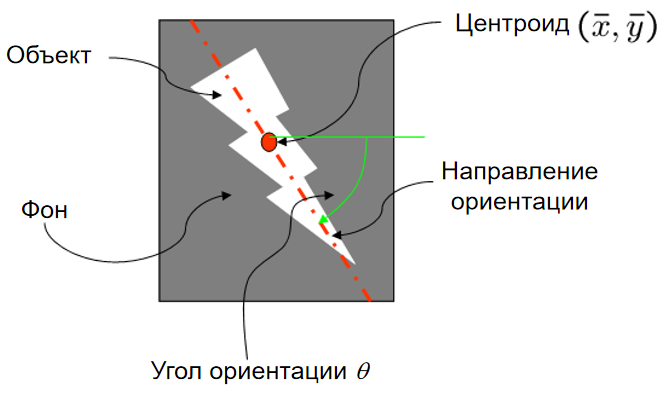

Применим это для определения направления объектов в пространстве

Угол ориентации в пространстве: 0.0°


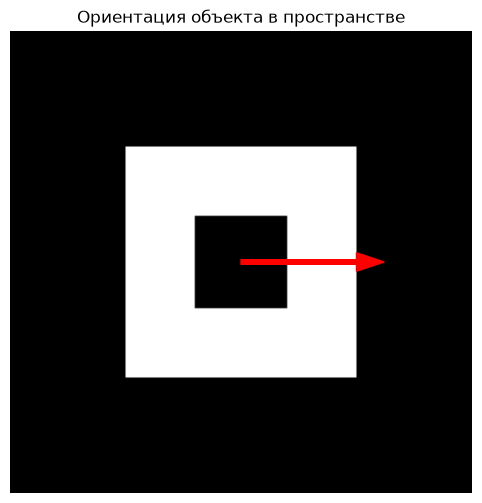

In [15]:
# Вычисление вторых центральных моментов
mu20 = np.sum((x1 - centroid_x1)**2)
mu02 = np.sum((y1 - centroid_y1)**2)
mu11 = np.sum((x1 - centroid_x1)*(y1 - centroid_y1))

angle = 0.5 * np.arctan2(2*mu11, mu20 - mu02)
angle_deg = np.degrees(angle)
print(f"Угол ориентации в пространстве: {angle_deg:.1f}°")

# Визуализируем направление
length = 50
dx = length * np.cos(angle)
dy = length * np.sin(angle)
plt.imshow(img1, cmap='gray')
plt.arrow(centroid_x1, centroid_y1, dx, dy, color='red', width=2, head_width=8)
plt.title('Ориентация объекта в пространстве')
plt.axis('off')
plt.show()

Угол ориентации в пространстве по моментам: 56.08° (задано 56°)


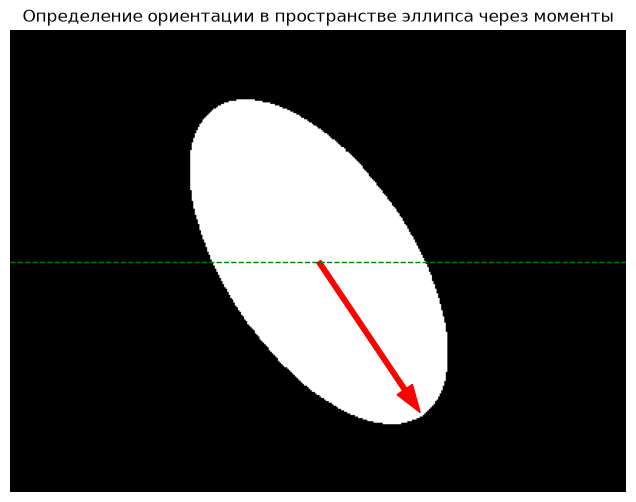

In [ ]:
# Вычисление вторых центральных моментов и ориентации
mu20 = np.sum((x2 - centroid_x2)**2)
mu02 = np.sum((y2 - centroid_y2)**2)
mu11 = np.sum((x2 - centroid_x2)*(y2 - centroid_y2))

angle_moment = 0.5 * np.arctan2(2*mu11, mu20 - mu02)
angle_moment_deg = np.degrees(angle_moment)
if angle_moment_deg < 0:
    angle_moment_deg += 180

print(f"Угол ориентации в пространстве по моментам: {angle_moment_deg:.2f}° (задано {angle_ellipse}°)")

# Рисуем стрелку вдоль большой оси эллипса
length = 100
dx = length * np.cos(np.radians(angle_moment_deg))
dy = length * np.sin(np.radians(angle_moment_deg))

plt.imshow(img2, cmap='gray')
plt.arrow(centroid_x2, centroid_y2, dx, dy, color='red', width=3, head_width=12)
plt.axhline(y=centroid_y2, color='green', linestyle='--', linewidth=1, label='Горизонталь через центроид')
plt.title('Определение ориентации в пространстве эллипса через моменты')
plt.axis('off')
plt.show()

Моменты дают угол с точностью до 180° (направление оси не различает «голову» и «хвост»). Для эллипса это неважно.

## 3. Базовые операции математической морфологии: дилатация и эрозия


### 1. Введение

**Математическая морфология** – это теория анализа геометрической структуры объектов, основанная на теории решёток и множеств. Создана в 1960-х годах Жоржем Матероном и Жаном Серра для анализа горных пород (стереология). Сегодня широко применяется в:
- обработке изображений (медицина, спутниковые снимки, распознавание символов);
- анализе графов и социальных сетей;
- топологическом анализе данных (TDA);
- предобработке данных для нейронных сетей.

**Почему морфология важна для алгоритмов искусственного интеллекта?**  
Она даёт детерминированные, интерпретируемые и быстрые алгоритмы для выделения признаков (таких как форма, размер, количество отверстий), фильтрации шума и восстановления структур. В отличие от нейросетей, не требует обучения и огромных данных.

### 2. Теоретические основы


#### 2.1. Бинарное изображение как множество
Бинарное изображение $I$ размером $M \times N$ можно интерпретировать как множество координат белых пикселей:
$$ A = \{ (x,y) \in \mathbb{Z}^2 \mid I(x,y) = 1 \} $$
Чёрный фон – дополнение $A^c = \mathbb{Z}^2 \setminus A$.

#### 2.2. Структурный элемент (SE)
Структурный элемент $B$ – это небольшое множество целых координат (обычно включающее начало координат). Примеры:
- Квадрат 3x3: $B = \{(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)\}$
- Крест 3x3: $B = \{(0,0), (0,1), (0,-1), (1,0), (-1,0)\}$
- Диск (эллипс) задаваемый радиусом.

#### 2.3. Операции сдвига и отражения
- Сдвиг множества $A$ на вектор $t$: $A_t = \{ a+t \mid a \in A \}$
- Отражение (симметрия) структурного элемента: $B^r = \{ -b \mid b \in B \}$

В большинстве библиотек SE симметричен, поэтому $B^r=B$.



### 3. Дилатация (расширение)



**Определение:**
$$ A \oplus B = \bigcup_{b \in B} (A + b) = \{ a+b \mid a \in A, b \in B \} $$
То есть объединение всех сдвигов $A$ на векторы из $B$.

**Геометрическая интерпретация:**  
Если поместить структурный элемент $B$ в каждую точку $a \in A$ и объединить все полученные копии, то получается расширенная область.

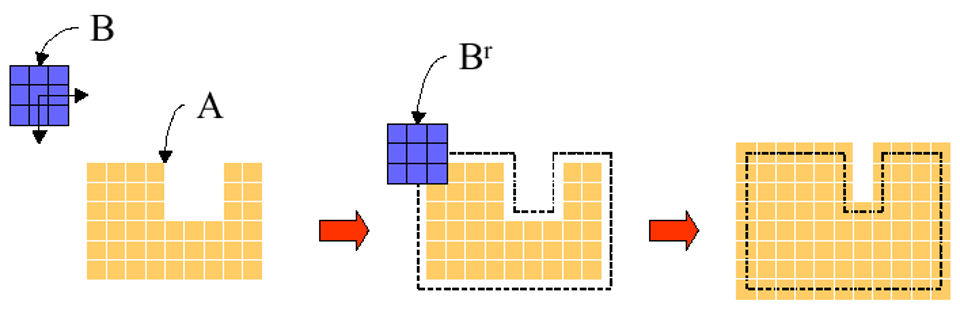

**Свойства дилатации:**
1. **Коммутативность:** $A \oplus B = B \oplus A$ — Дилатация множества $A$ структурным элементом $B$ — это то же самое, что дилатация $B$ элементом $A$.
2. **Ассоциативность:** $(A \oplus B) \oplus C = A \oplus (B \oplus C)$ — При последовательном применении дилатации группировка не имеет значения. Это позволяет, например, разложить сложный структурный элемент на последовательность более простых.
3. **Монотонность:** если $A_1 \subseteq A_2$, то $A_1 \oplus B \subseteq A_2 \oplus B$ — Если одно множество целиком содержится в другом, то и результат их дилатации сохраняет это отношение вложения. Большее множество после дилатации остается большим или равным.
4. **Расширение:** $A \subseteq A \oplus B$, если $0 \in B$ — Если структурный элемент \(B\) содержит центр (начало координат), то дилатация не уменьшает исходное множество, а только расширяет его (или оставляет прежним).
5. **Дистрибутивность относительно объединения:** $(A \cup B) \oplus C = (A \oplus C) \cup (B \oplus C)$ — Дилатация объединения множеств равна объединению результатов дилатации каждого множества в отдельности. Это ключевое свойство для реализации операций.


### 4. Эрозия (сужение)

**Определение:**
$$ A \ominus B = \{ x \mid B + x \subseteq A \} $$
Все точки $x$, для которых сдвинутый структурный элемент $B$ целиком лежит внутри $A$.


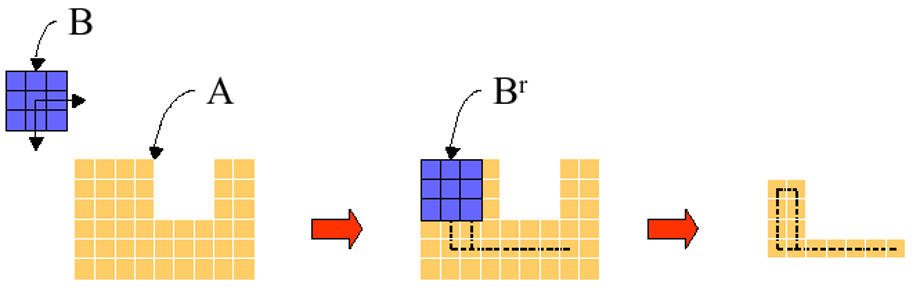


**Геометрическая интерпретация:**  
Если провести структурным элементом по изображению, оставляя только те позиции, где структурный элемент полностью перекрывается с объектом, то получится результат эрозии.

**Свойства эрозии:**
1. **Монотонность:** если $A_1 \subseteq A_2$, то $A_1 \ominus B \subseteq A_2 \ominus B$ — Если мы берем меньшее множество (изображение $A_{1}$) и применяем к нему эрозию со структурирным элементом $B$, результат будет подмножеством результата эрозии большего множества (изображения $A_{2}$).Операция сохраняет порядок включения. Чем меньше исходный объект, тем меньше он становится после эрозии.
2. **Антиэкстенсивность:** $A \ominus B \subseteq A$ (если $0 \in B$) — Результат эрозии всегда содержится в исходном множестве $A$, при условии, что начало координат (0 или центр) входит в структурный элемент $B$. Эрозия только уменьшает объект (или оставляет его прежним), но никогда не расширяет его.
3. **Дистрибутивность относительно пересечения:** $(A \cap B) \ominus C = (A \ominus C) \cap (B \ominus C)$ — Эрозия пересечения двух множеств равна пересечению результатов эрозии этих множеств по отдельности. Операция эрозии "распределяется" по оператору пересечения.

**Пример:**  
Пусть объект - квадрат 10x10, а SE – квадрат 3x3. Эрозия даст квадрат 8x8, так как эрозия "съест" по 1 пикселю с каждой стороны.



### 5. Структурные элементы: формы и размеры



Выбор SE критически важен. Параметры:
- **Размер** (3x3, 5x5, 7x7) – чем больше, тем сильнее изменение.
- **Форма**:
  - Квадрат – изотропное расширение/сужение.
  - Крест – только по осям, сохраняет диагональные элементы.
  - Диск – более круглая форма, лучше для обработки природных объектов.
- **Наличие центра** – обычно SE содержит начало координат; иначе операция может смещать объект.

**Примеры в OpenCV:**
```python
cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))   # квадрат
cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5)) # крест
cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)) # эллипс/диск
```

---

### 6. Многократное применение (итерации)



OpenCV позволяет указать `iterations = k`. Это эквивалентно:
$$ \text{dilate}(A, B, k) = A \oplus B \oplus B \oplus \dots \oplus B \ (k\ \text{раз}) = A \oplus (B \oplus B \oplus \dots \oplus B) $$


**Замечание:** много итераций приводит к быстрому исчезновению малых объектов (эрозия) или их слиянию (дилатация).



### 7. Алгоритмическая реализация и сложность



Наивный алгоритм для каждого пикселя проверяет все точки SE. Сложность $O(\text{размер изображения} \times \text{размер SE})$. Оптимизируют с помощью:
- разложения SE на одномерные компоненты (сепарабельные SE);
- использования БПФ для больших SE (редко);
- аппаратной поддержки (GPU).

В OpenCV реализованы высокоэффективные алгоритмы, работающие за $O(MN)$ для большинства SE.



### 8. Расширение на полутоновые изображения



В этой лекции мы работаем с бинарными изображениями, но понимание обобщения важно, поэтому отмечу, что для полутоновых (grayscale) изображений $f: \mathbb{Z}^2 \to \mathbb{R}$ операции обобщаются с помощью **инфимума** и **супремума**:
- Дилатация: $(f \oplus b)(x) = \sup_{z \in B} f(x-z) + b(z)$
- Эрозия: $(f \ominus b)(x) = \inf_{z \in B} f(x+z) - b(z)$

Эти операции используются для морфологического градиента, фильтрации, выделения ярких/тёмных структур.


### 9. Практическая часть в Google Colab

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, morphology

plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

#### 9.1. Создание тестовых изображений

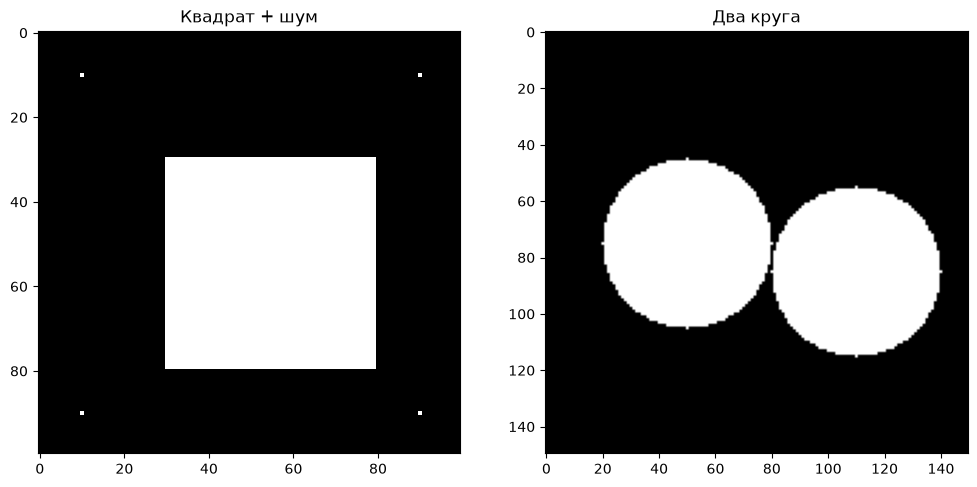

In [17]:
# Изображение 1: квадрат с шумом в углах
img1 = np.zeros((100,100), np.uint8)
img1[30:80, 30:80] = 1
img1[10,10] = 1; img1[90,90] = 1; img1[10,90] = 1; img1[90,10] = 1

# Изображение 2: два разделённых круга
img2 = np.zeros((150,150), np.uint8)
cv2.circle(img2, (50,75), 30, 1, -1)
cv2.circle(img2, (110,85), 30, 1, -1)

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(img1, cmap='gray'); ax1.set_title('Квадрат + шум')
ax2.imshow(img2, cmap='gray'); ax2.set_title('Два круга')
plt.show()

#### 9.2. Дилатация – соединяем круги

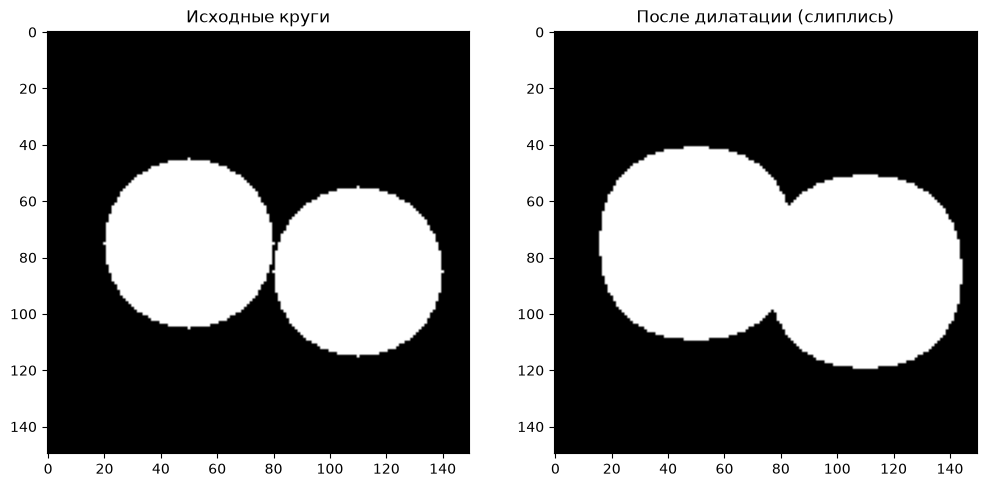

In [18]:
kernel = np.ones((5,5), np.uint8)   # квадратный SE 5x5
dilated_circles = cv2.dilate(img2, kernel, iterations=2)

plt.subplot(1,2,1); plt.imshow(img2, cmap='gray'); plt.title('Исходные круги')
plt.subplot(1,2,2); plt.imshow(dilated_circles, cmap='gray'); plt.title('После дилатации (слиплись)')
plt.show()

#### 9.3. Эрозия – удаляем шум и отделяем объекты

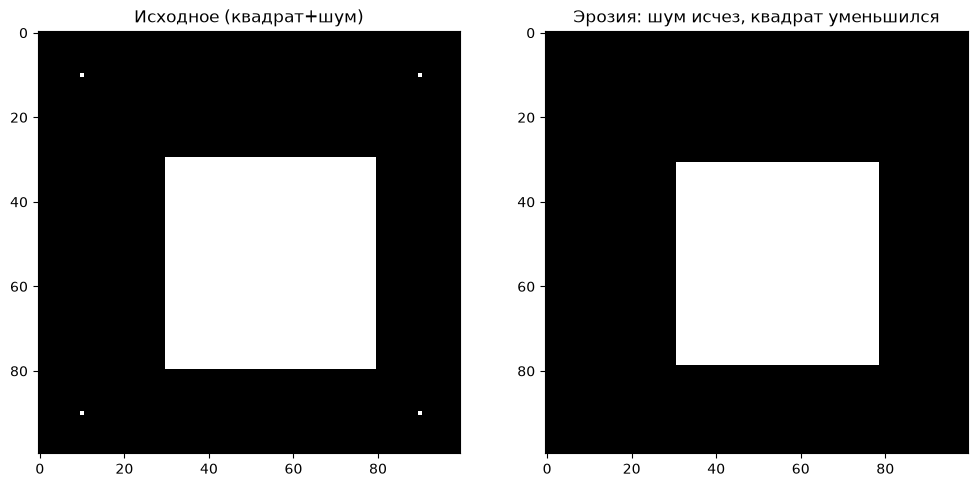

In [19]:
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
eroded1 = cv2.erode(img1, kernel, iterations=1)

plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.title('Исходное (квадрат+шум)')
plt.subplot(1,2,2); plt.imshow(eroded1, cmap='gray'); plt.title('Эрозия: шум исчез, квадрат уменьшился')
plt.show()

#### 9.4. Итерации: увеличение силы воздействия

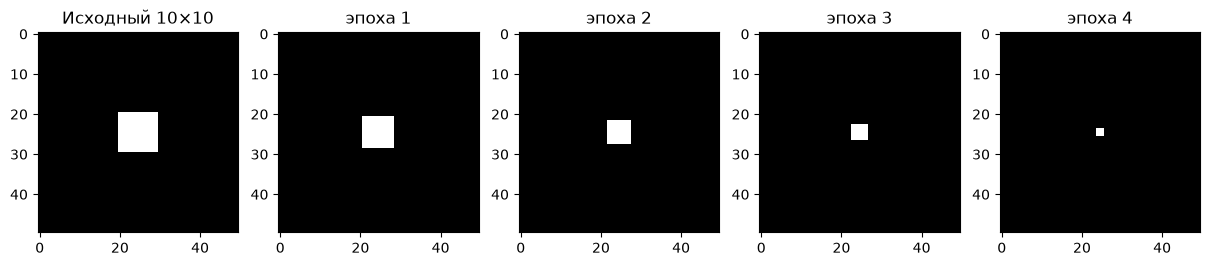

In [23]:
img_test = np.zeros((50,50), np.uint8)
img_test[20:30,20:30] = 1
kernel = np.ones((3,3), np.uint8)

fig, axes = plt.subplots(1,5, figsize=(15,3))
axes[0].imshow(img_test, cmap='gray'); axes[0].set_title('Исходный 10×10')
for i in range(1,5):
    eroded_i = cv2.erode(img_test, kernel, iterations=i)
    axes[i].imshow(eroded_i, cmap='gray')
    axes[i].set_title(f'эпоха {i}')
plt.show()

Видно, что после 4 итераций объект почти исчезает.



## Пример выполнения рассмотренных операций на загруженном изображении

Загрузим изображение (желательно бинарное: чёрно-белое без полутонов). Если изображение цветное или полутоновое, оно будет автоматически преобразовано в бинарное по методу Оцу (Otsu) https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%9E%D1%86%D1%83.

Saving img1.png to img1.png
Изображение загружено: img1.png, размер (259, 194)


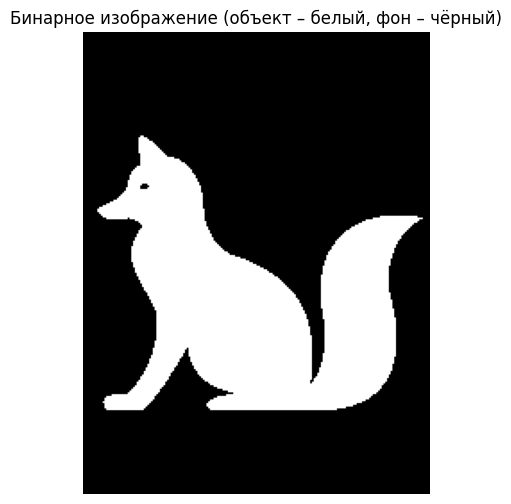

In [15]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Чтение изображения в градациях серого
img_gray = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Бинаризация методом Оцу (инвертируем, чтобы объект был белым, фон чёрным)
_, img_bin = cv2.threshold(img_gray, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Изображение загружено: {filename}, размер {img_bin.shape}")
plt.imshow(img_bin, cmap='gray')
plt.title('Бинарное изображение (объект – белый, фон – чёрный)')
plt.axis('off')
plt.show()

### Центроид и ориентация объекта

Вычисляем площадь (нулевой момент), центроид (первые моменты) и угол ориентации (вторые центральные моменты).

**Внимание:** изображение должно содержать **один связный объект** (иначе центроид будет общим для всех).

In [16]:
# Находим координаты белых пикселей (объект)
y, x = np.where(img_bin == 1)
if len(x) == 0:
    raise ValueError("На изображении нет белых пикселей!")

In [17]:
# Площадь
area = len(x)
print(f"Площадь объекта: {area} пикселей")

Площадь объекта: 13456 пикселей


In [18]:
# Центроид
centroid_x = np.mean(x)
centroid_y = np.mean(y)
print(f"Центроид: ({centroid_x:.1f}, {centroid_y:.1f})")

Центроид: (94.9, 152.2)


In [19]:
# Вторые центральные моменты
mu20 = np.sum((x - centroid_x)**2)
mu02 = np.sum((y - centroid_y)**2)
mu11 = np.sum((x - centroid_x)*(y - centroid_y))

In [ ]:
# Угол ориентации (формула)
angle = 0.5 * np.arctan2(2*mu11, mu20 - mu02)
angle_deg = np.degrees(angle)
if angle_deg < 0:
    angle_deg += 180
print(f"Угол ориентации (большая ось): {angle_deg:.2f}°")

Угол ориентации (большая ось): 25.72°


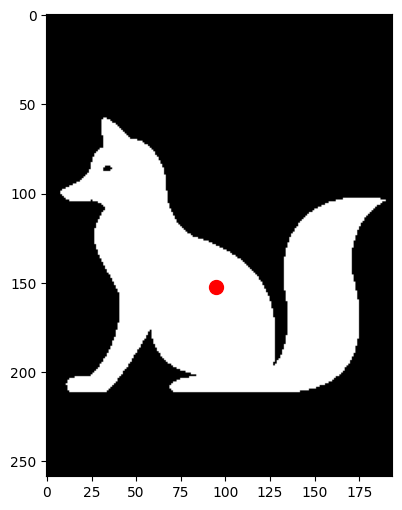

In [21]:
# Визуализация центроида
plt.imshow(img_bin, cmap='gray')
plt.plot(centroid_x, centroid_y, 'ro', markersize=10)

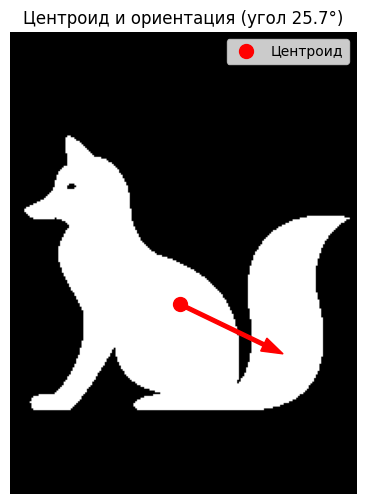

In [22]:
# Визуализация центроида и оси
plt.imshow(img_bin, cmap='gray')
plt.plot(centroid_x, centroid_y, 'ro', markersize=10, label='Центроид')
# Рисуем стрелку вдоль большой оси
length = min(img_bin.shape) // 3
dx = length * np.cos(np.radians(angle_deg))
dy = length * np.sin(np.radians(angle_deg))
plt.arrow(centroid_x, centroid_y, dx, dy, color='red', width=2, head_width=8, length_includes_head=True)
plt.title(f'Центроид и ориентация (угол {angle_deg:.1f}°)')
plt.axis('off')
plt.legend()
plt.show()

### Функция для морфологических операций

Создадим функцию `apply_morphology(image, operation, se_type, kernel_size, iterations)`, которая имеет параметры:
- operation: реализует методы `'dilate'` или `'erode'`
- se_type: позволяет выбрать структурный элемент `'rect'` (квадрат), `'cross'` (крест), `'ellipse'` (эллипс)
- kernel_size: размер ядра (3,5,7,...)
- iterations: число итераций

Функция возвращает преобразованное изображение.

In [23]:
def apply_morphology(image, operation, se_type, kernel_size, iterations=1):
    """
    image: бинарное изображение (uint8, значения 0 или 1)
    operation: 'dilate' или 'erode'
    se_type: 'rect', 'cross', 'ellipse'
    kernel_size: размер ядра (нечётное число, например 3,5,7)
    iterations: количество повторений
    """
    # Преобразуем в формат OpenCV (0/255)
    img_255 = (image * 255).astype(np.uint8)

    # Выбор типа структурного элемента
    if se_type == 'rect':
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    elif se_type == 'cross':
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    elif se_type == 'ellipse':
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    else:
        raise ValueError("se_type must be 'rect', 'cross' or 'ellipse'")

    # Применение операции
    if operation == 'dilate':
        result = cv2.dilate(img_255, kernel, iterations=iterations)
    elif operation == 'erode':
        result = cv2.erode(img_255, kernel, iterations=iterations)
    else:
        raise ValueError("operation must be 'dilate' or 'erode'")

    # Возвращаем бинарное (0/1)
    return (result // 255).astype(np.uint8)

### Демонстрация дилатации

Будем перебирать:
- Типы SE: крест, эллипс, квадрат
- Размеры ядра: 3, 5, 7
- Итерации: 1, 2, 3

Для каждой комбинации показываем исходное изображение (слева) и результат (справа).

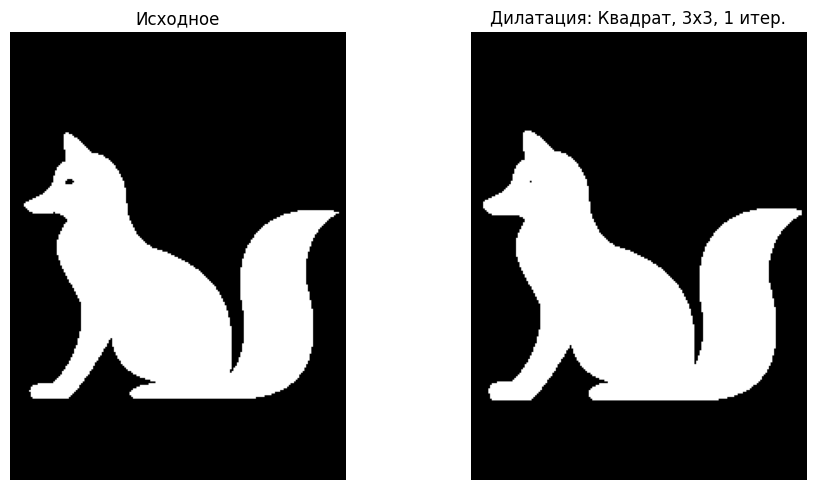

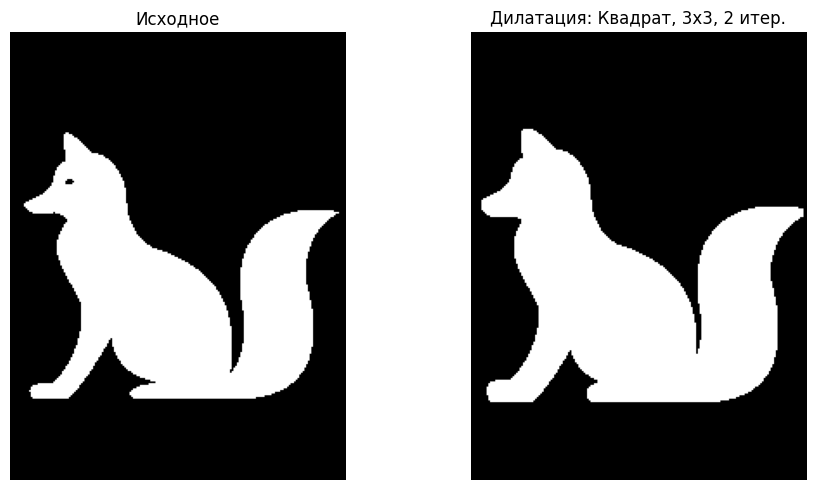

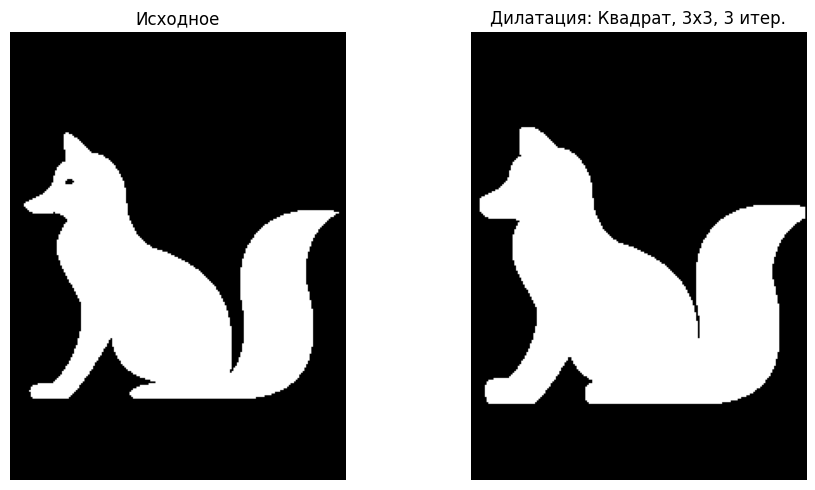

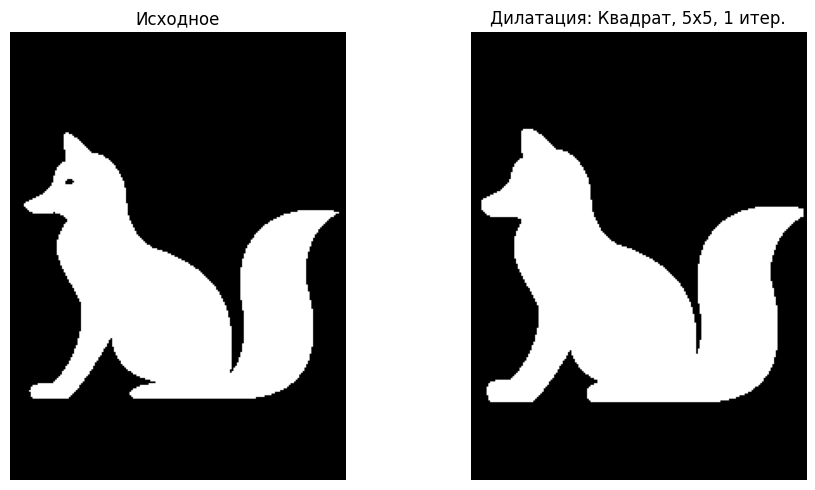

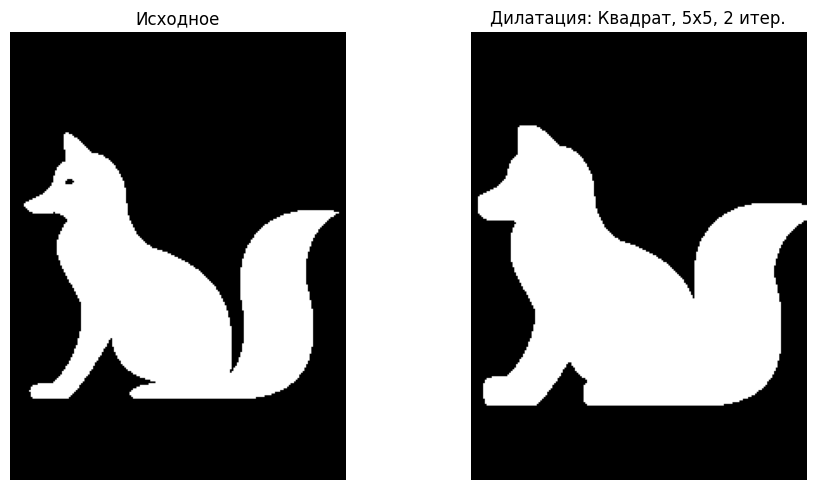

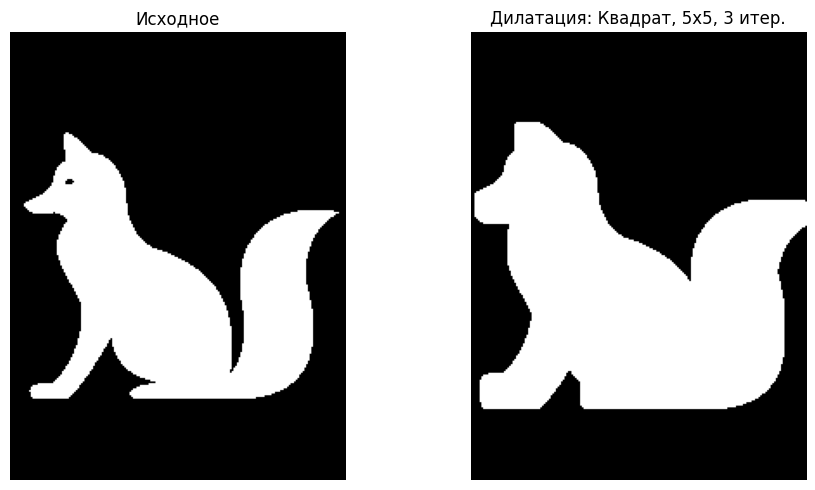

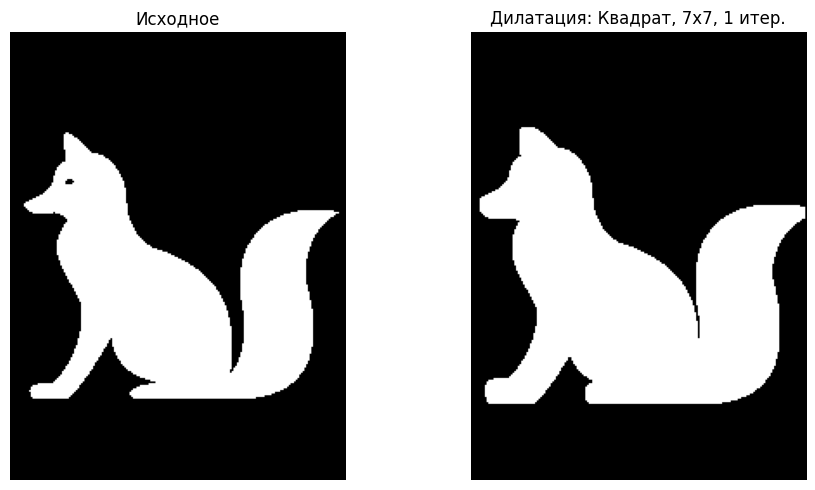

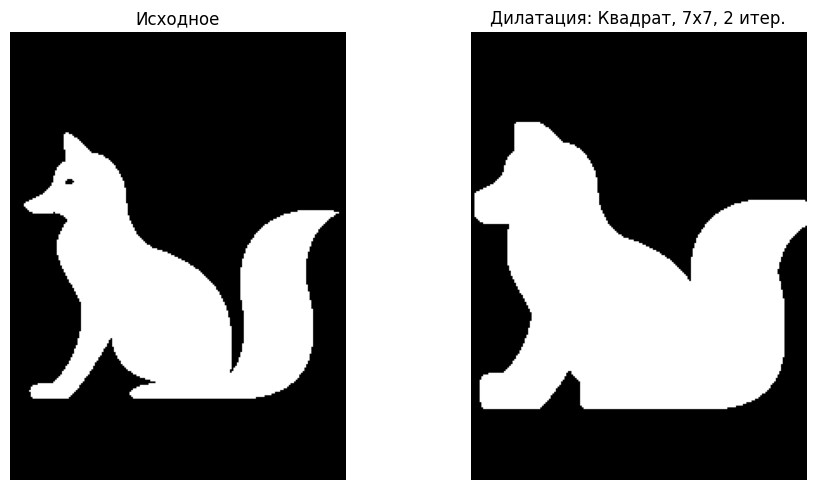

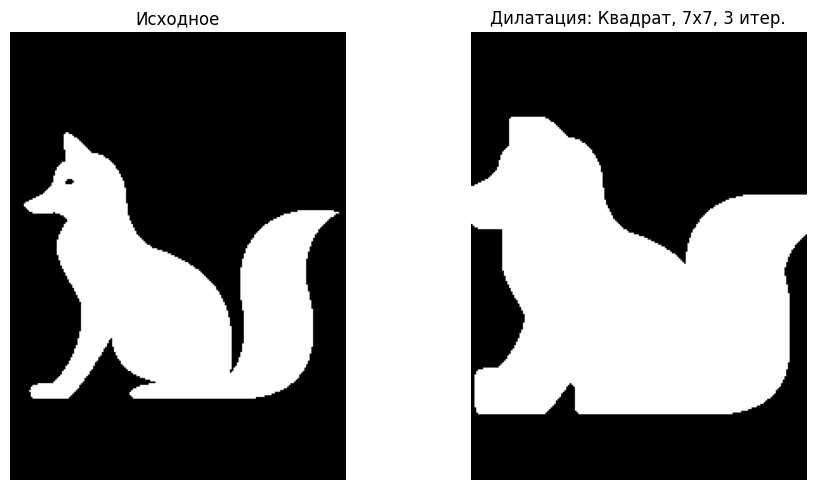

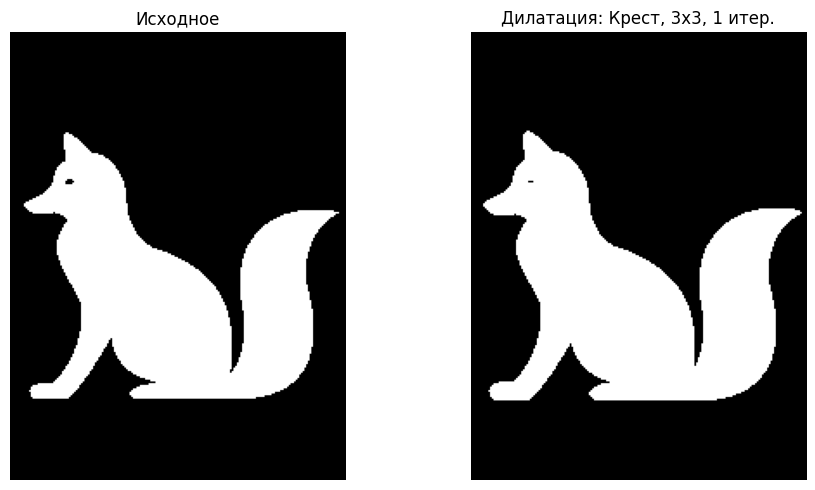

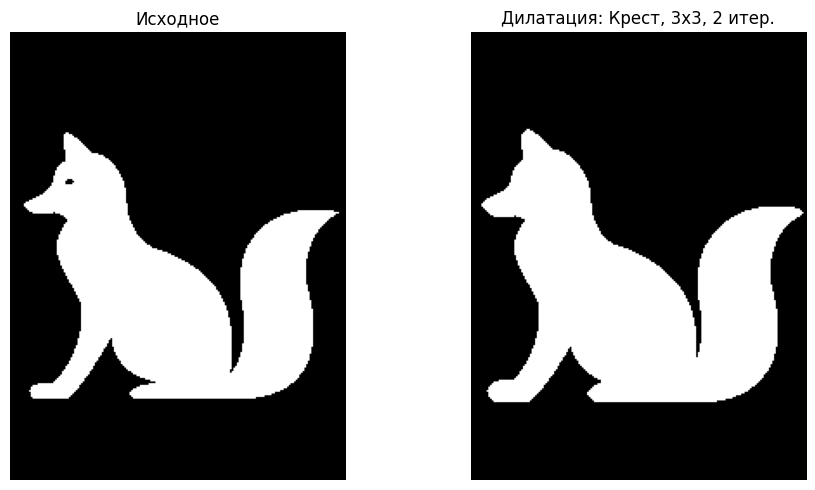

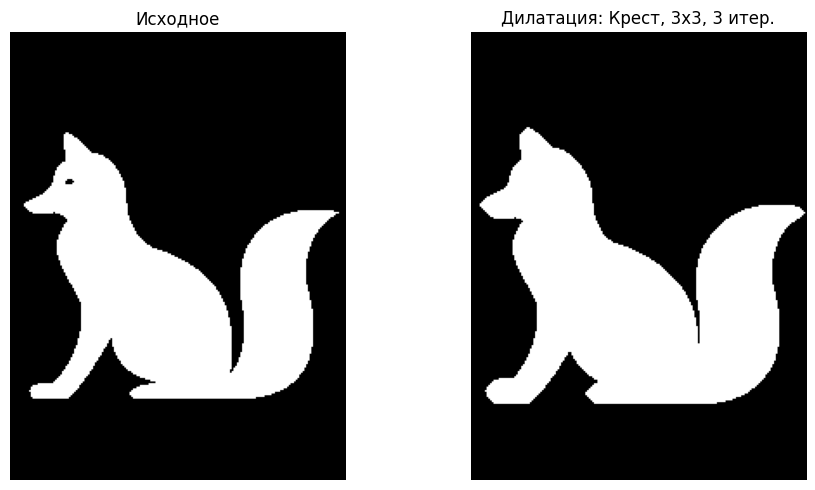

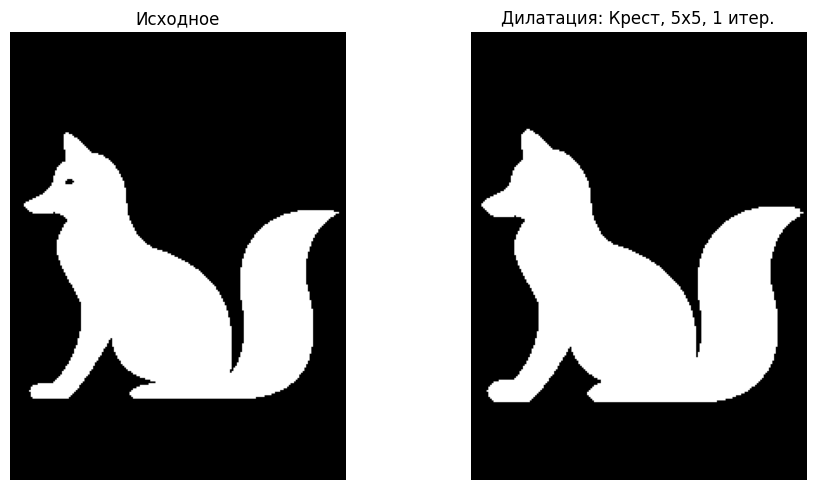

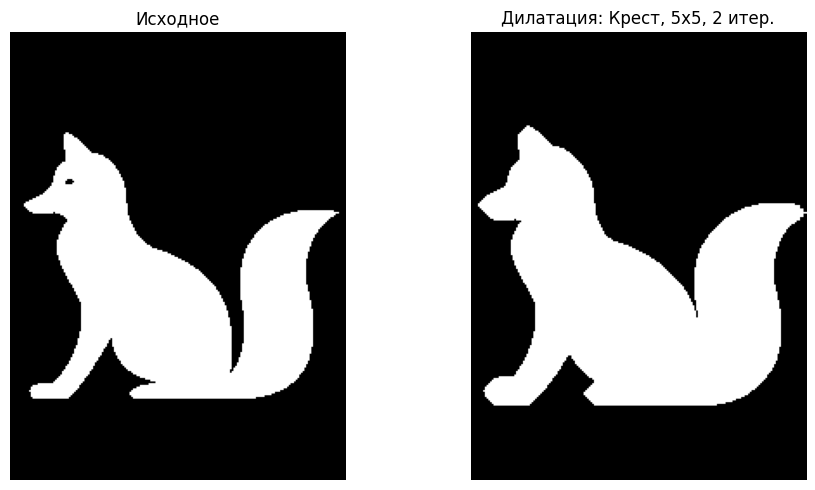

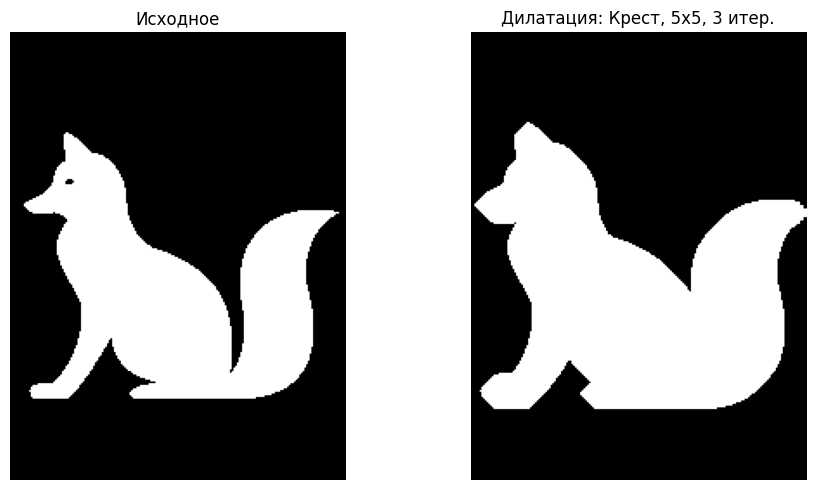

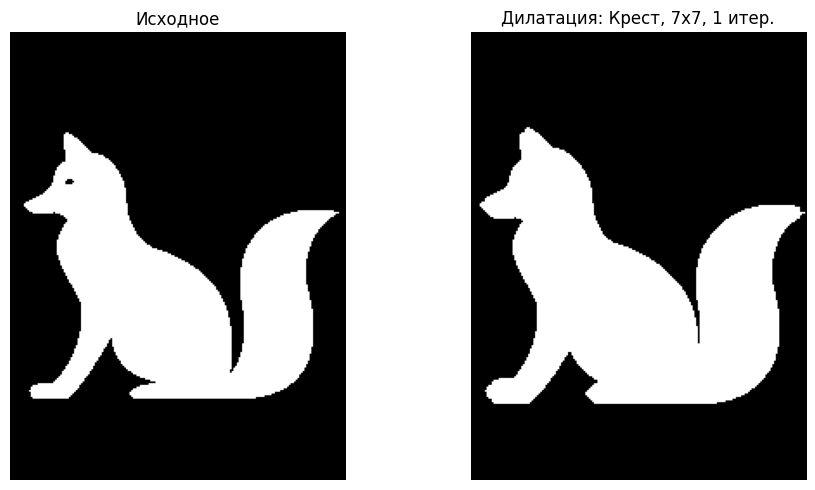

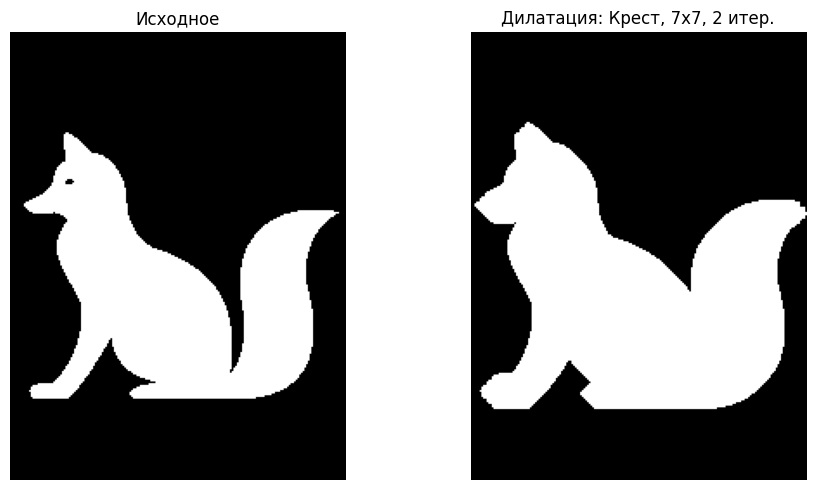

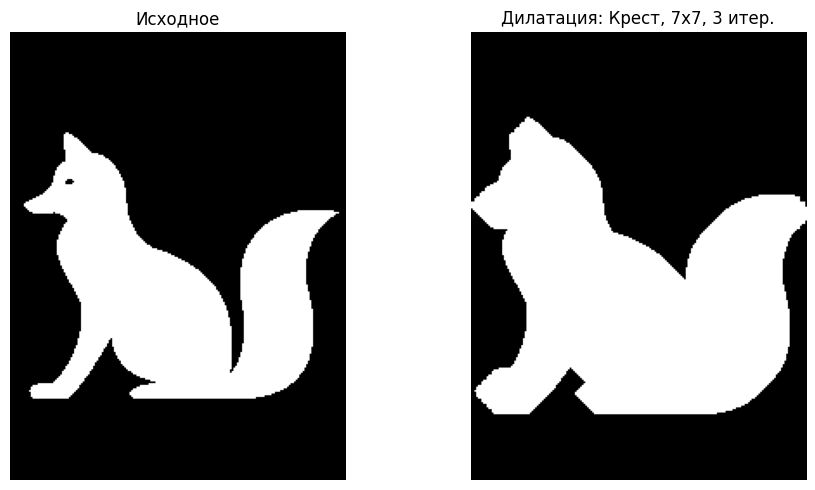

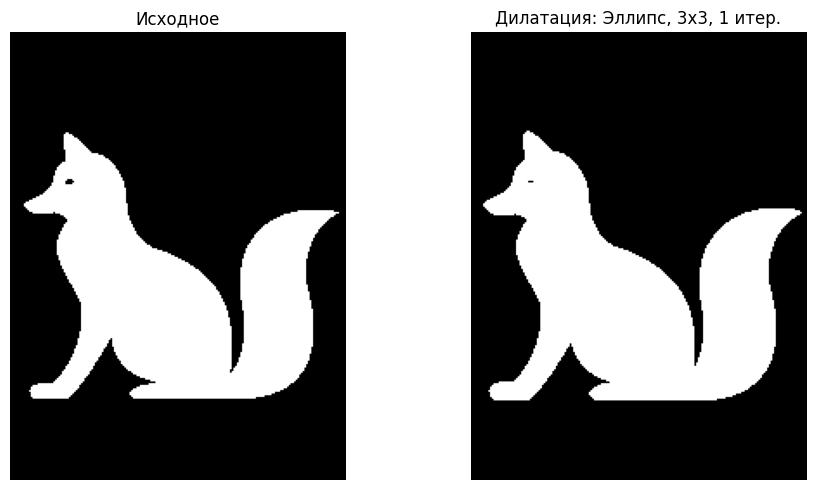

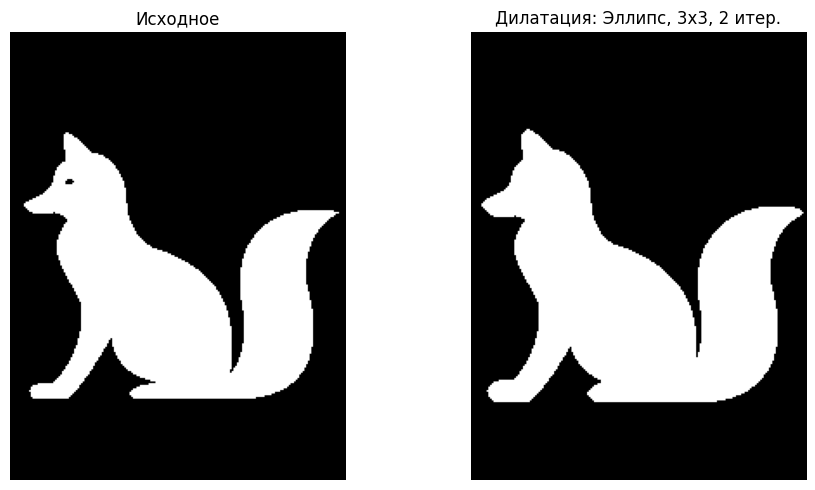

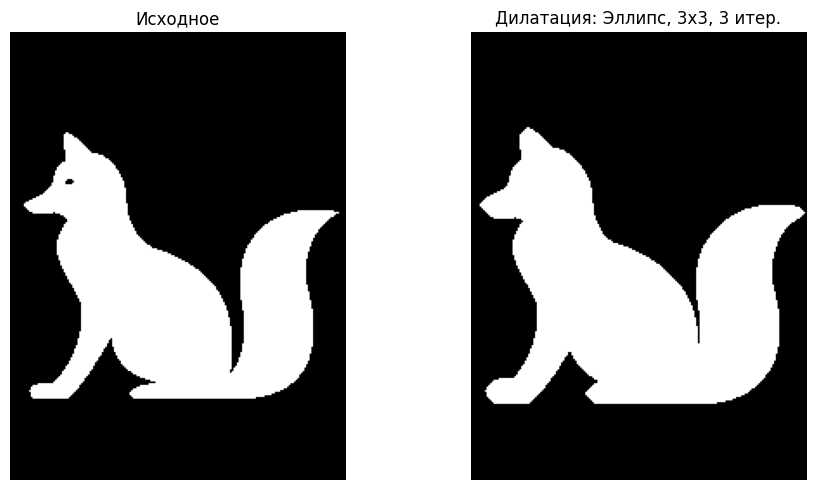

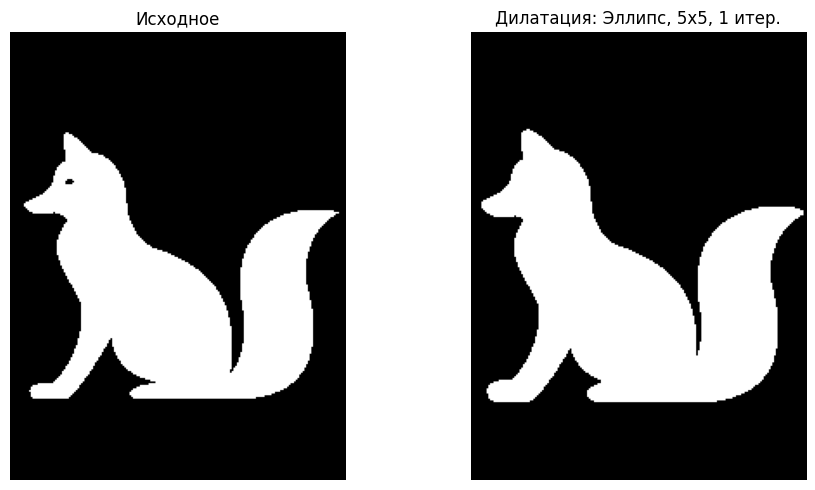

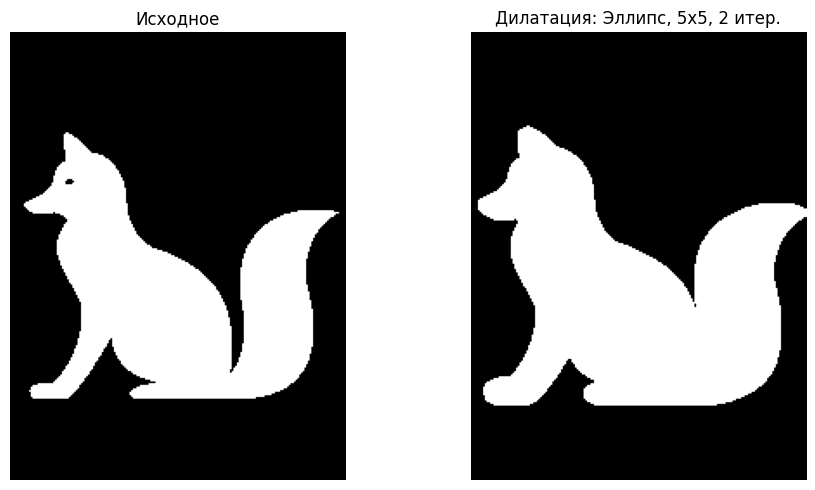

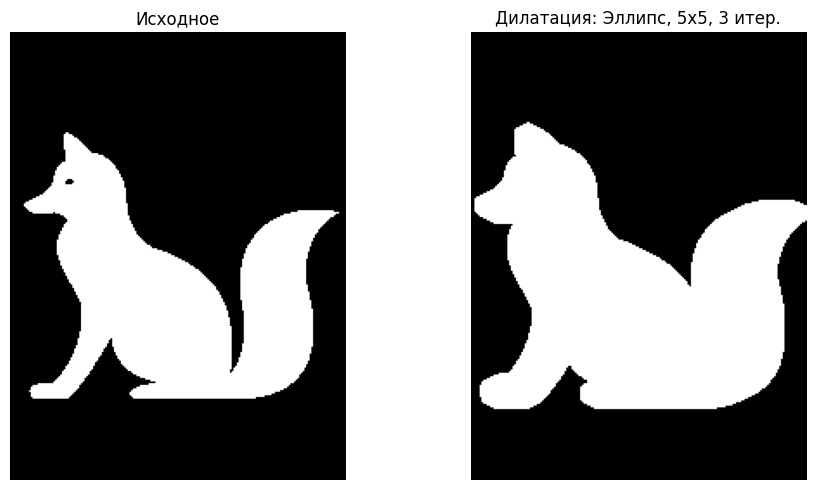

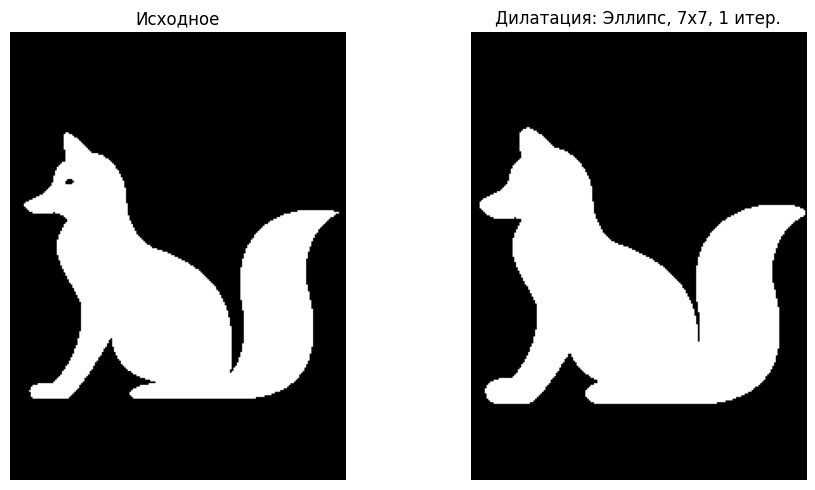

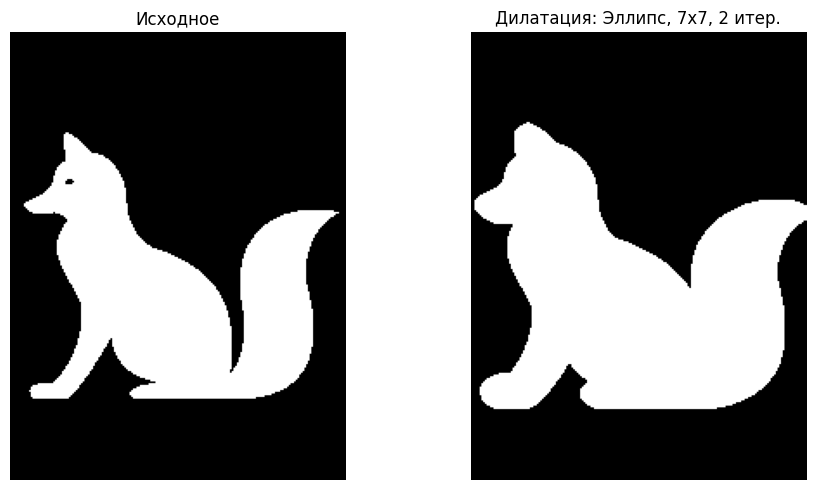

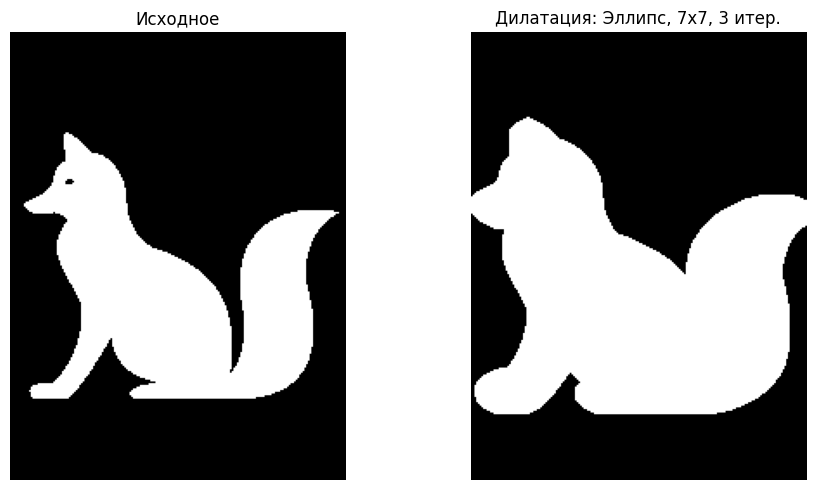

In [24]:
se_types = ['rect', 'cross', 'ellipse']
se_names = {'rect': 'Квадрат', 'cross': 'Крест', 'ellipse': 'Эллипс'}
kernel_sizes = [3, 5, 7]
iterations_list = [1, 2, 3]

for se in se_types:
    for ksize in kernel_sizes:
        for it in iterations_list:
            result = apply_morphology(img_bin, 'dilate', se, ksize, it)

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(img_bin, cmap='gray')
            axes[0].set_title('Исходное')
            axes[0].axis('off')
            axes[1].imshow(result, cmap='gray')
            axes[1].set_title(f'Дилатация: {se_names[se]}, {ksize}x{ksize}, {it} итер.')
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()

### Демонстрация эрозии

Аналогично для эрозии.

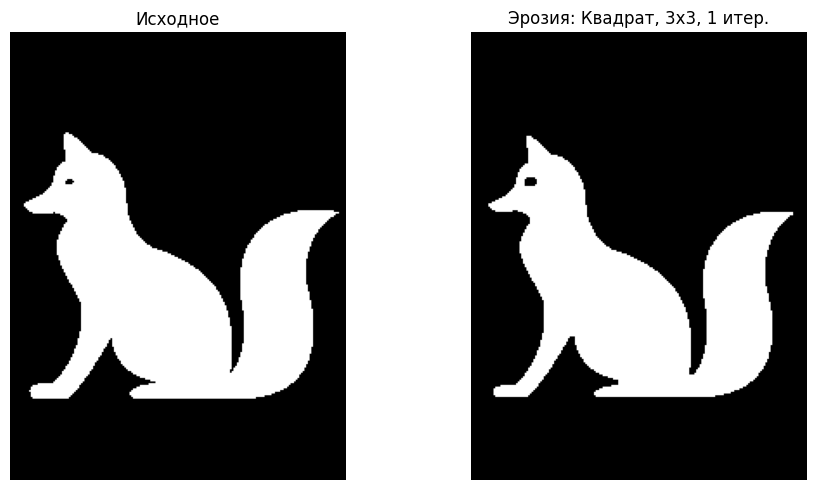

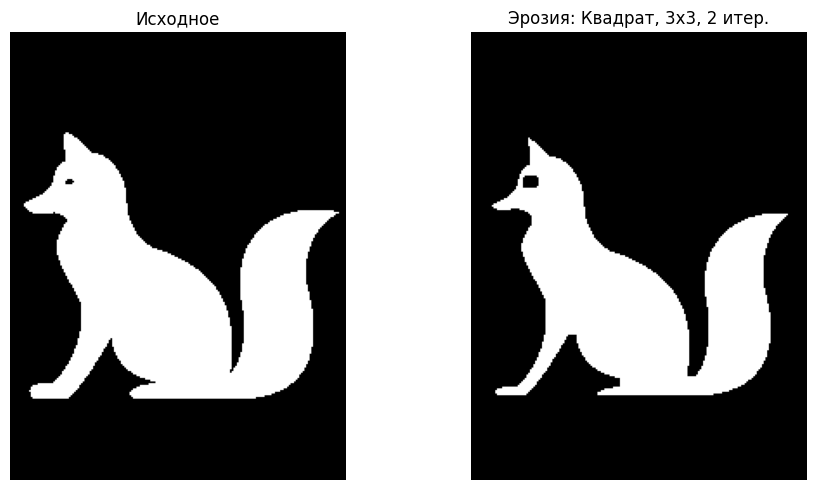

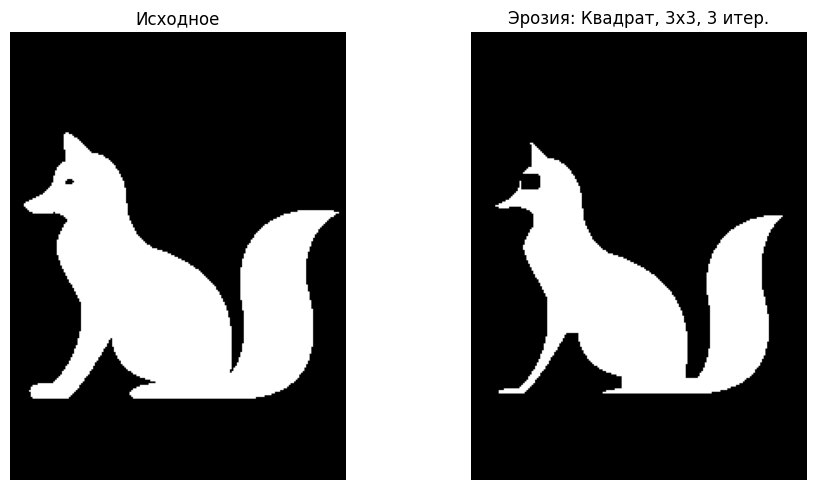

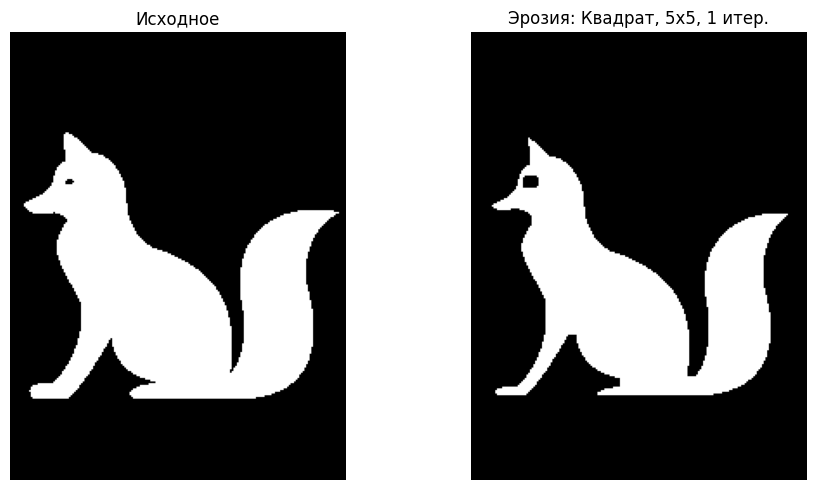

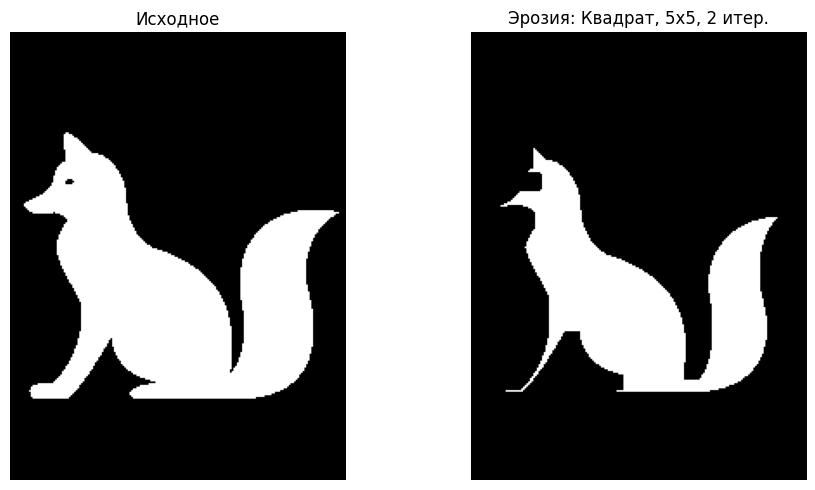

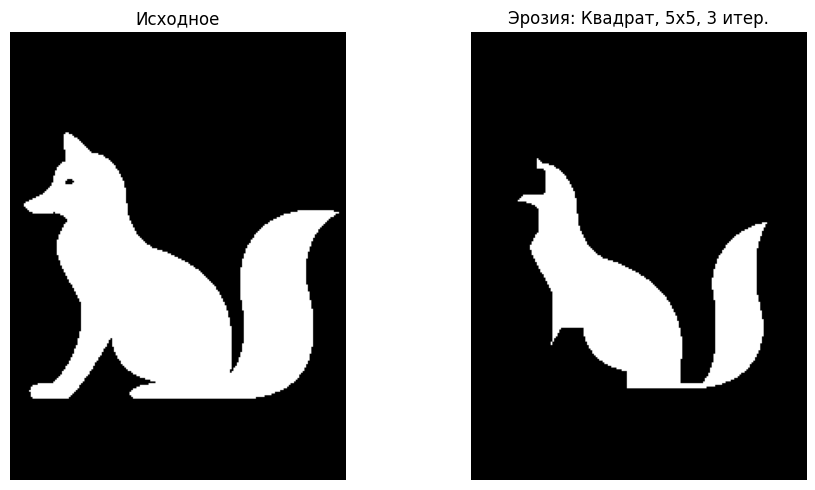

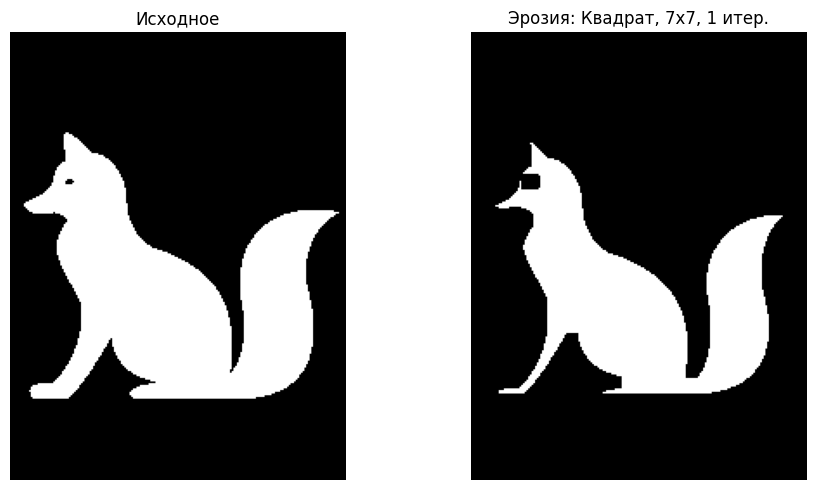

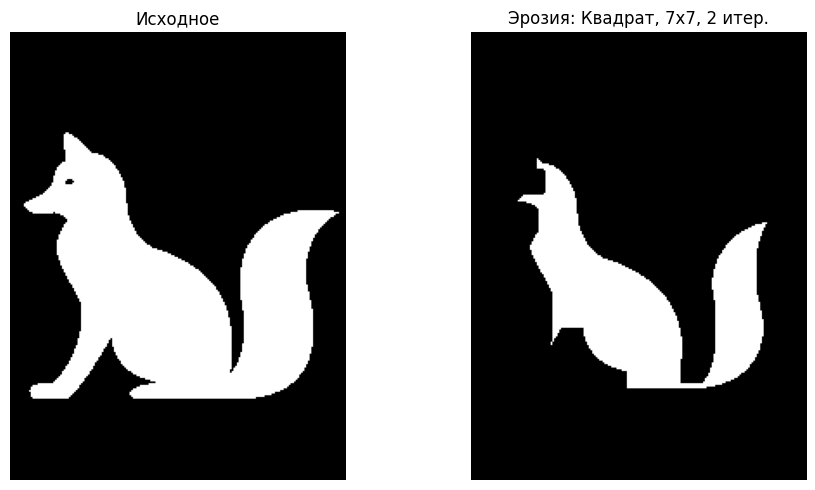

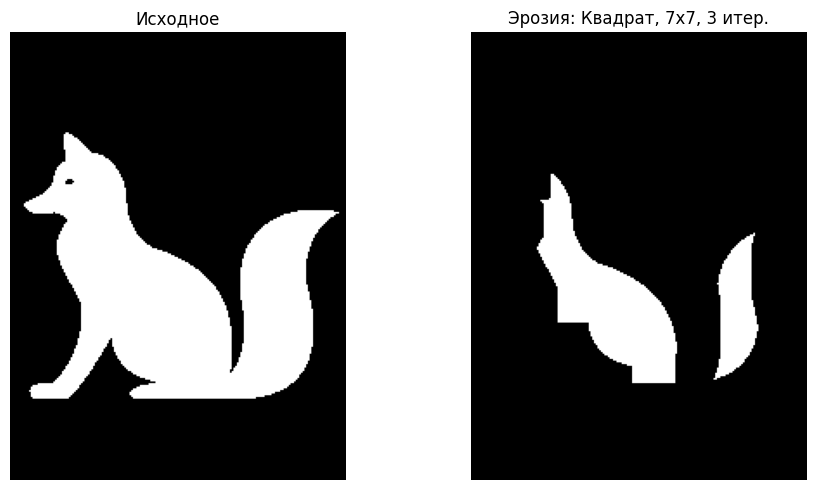

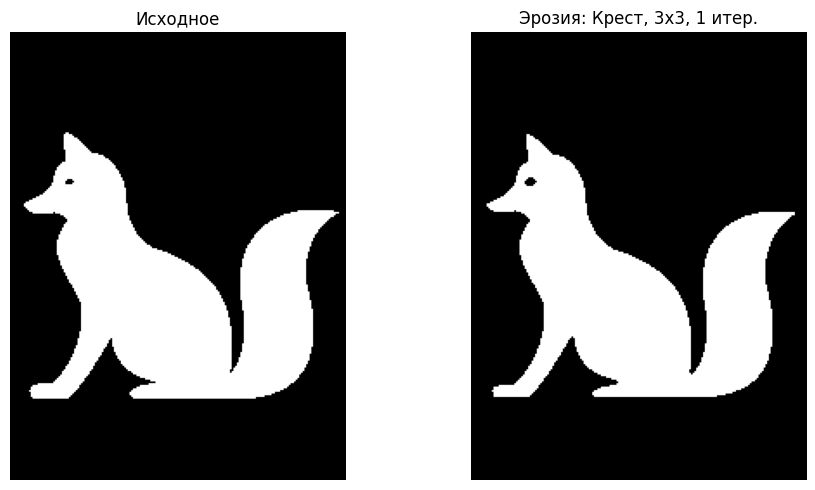

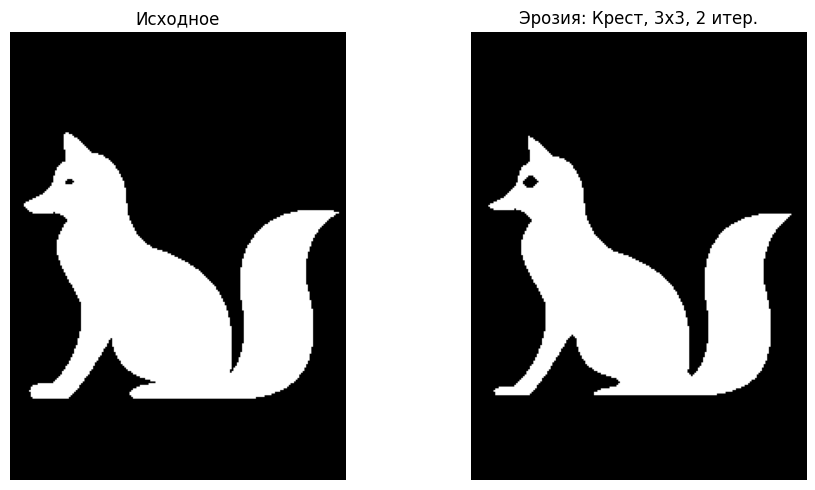

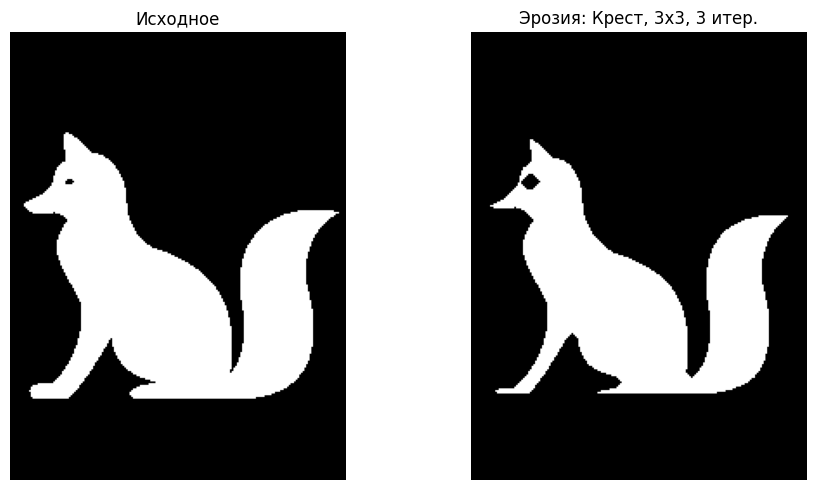

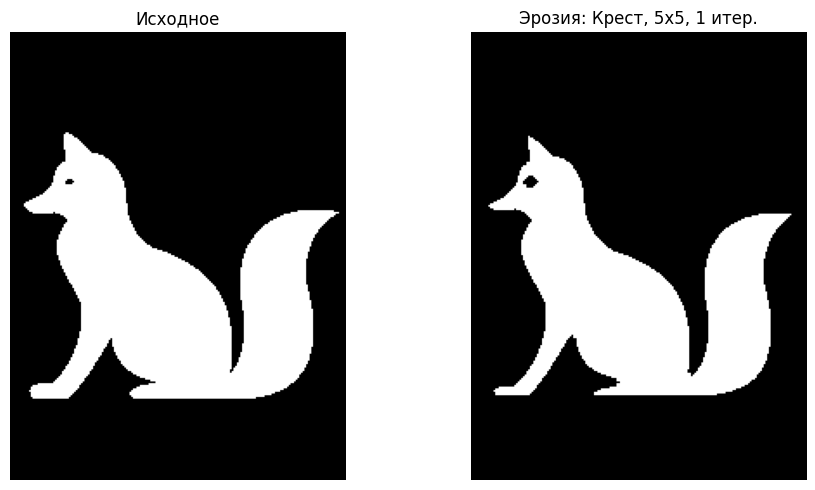

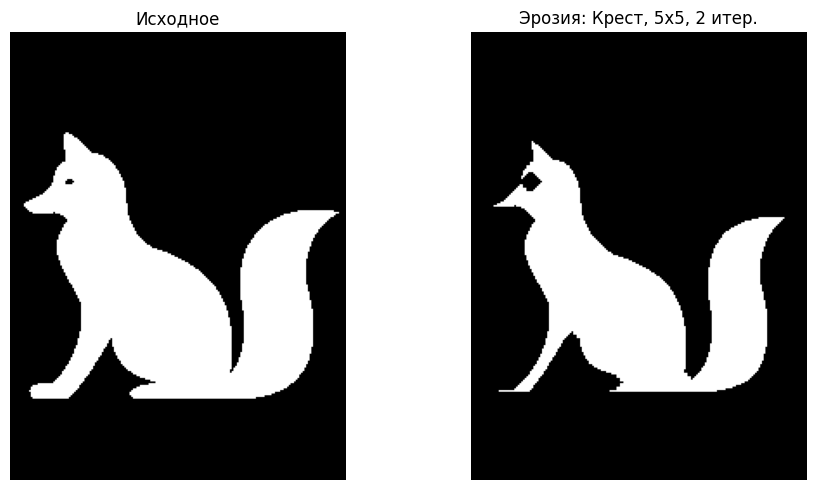

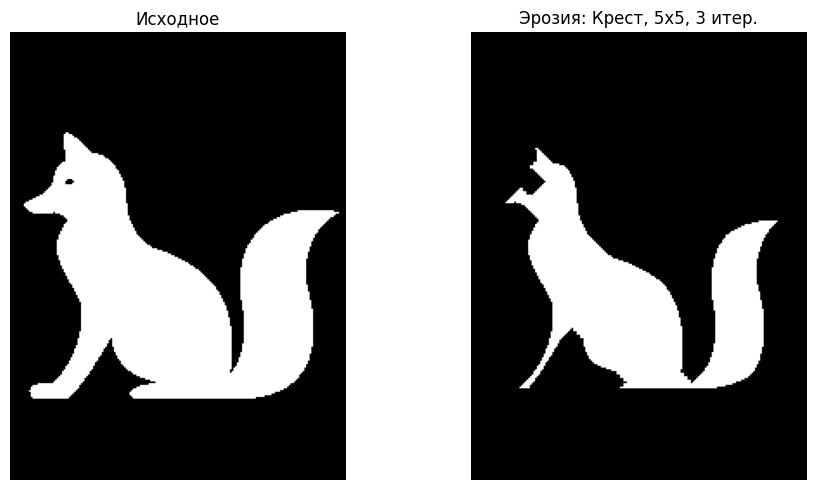

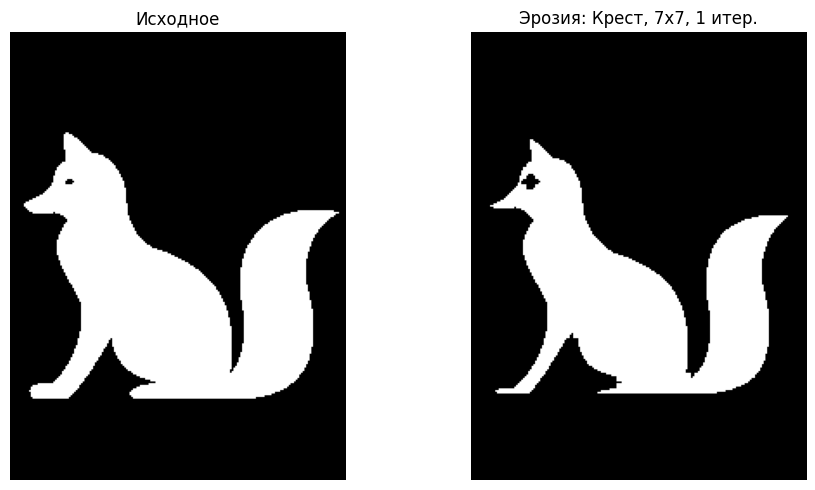

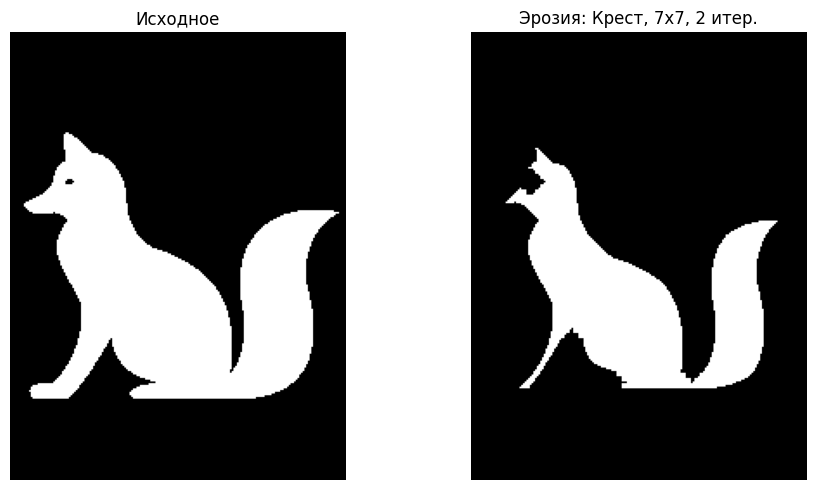

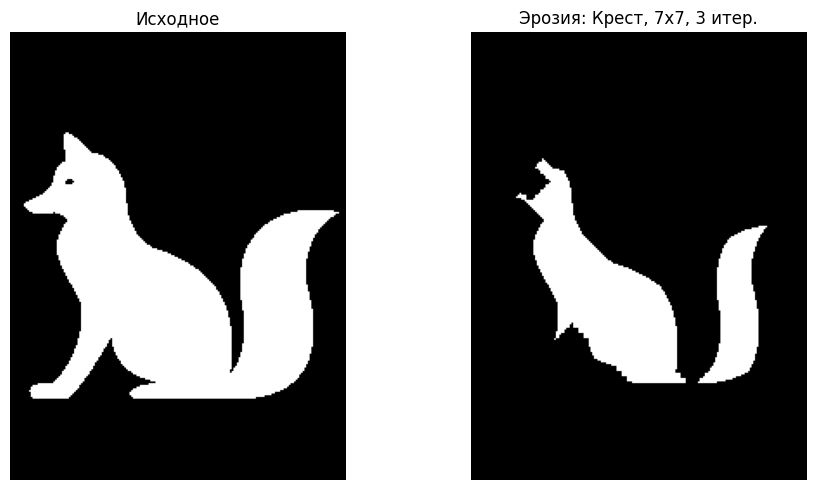

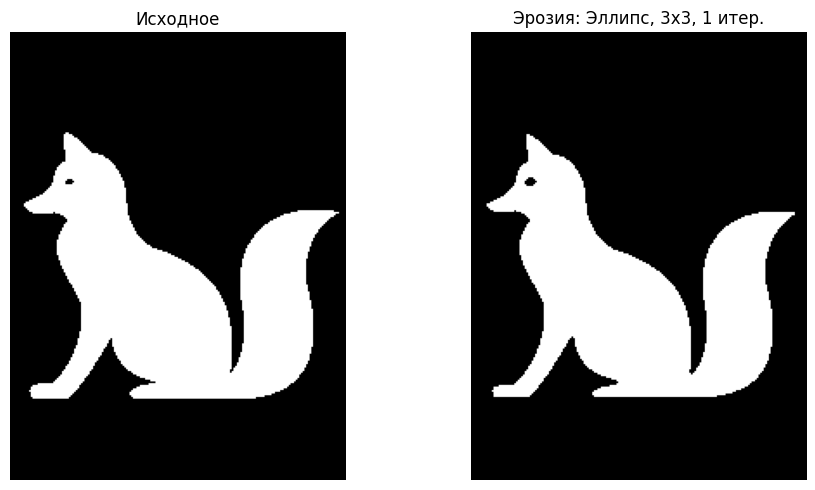

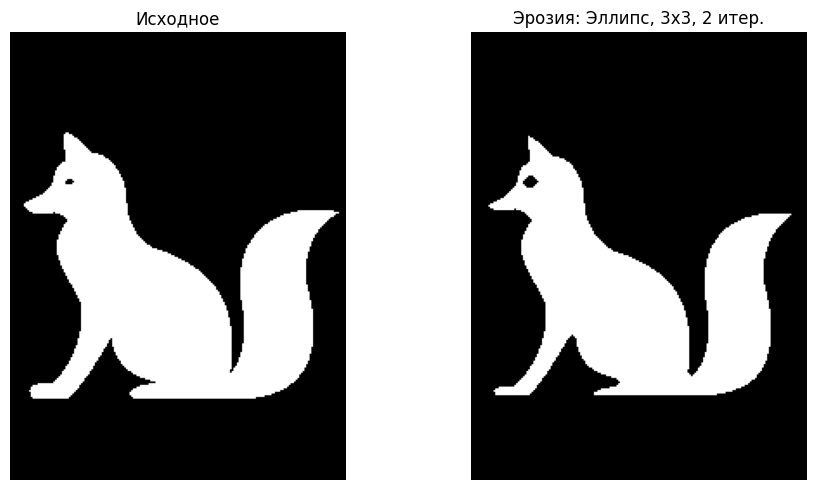

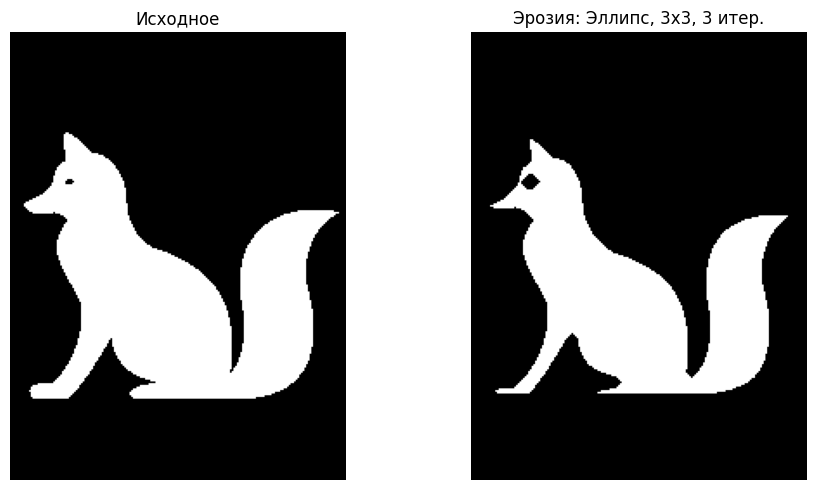

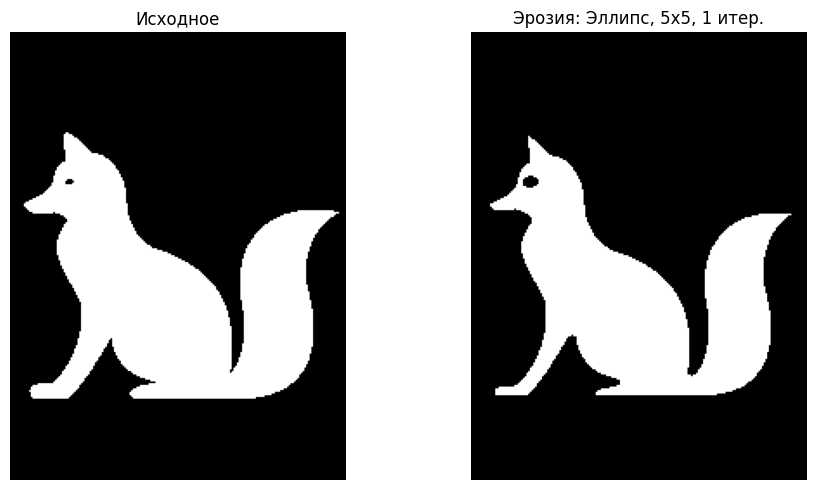

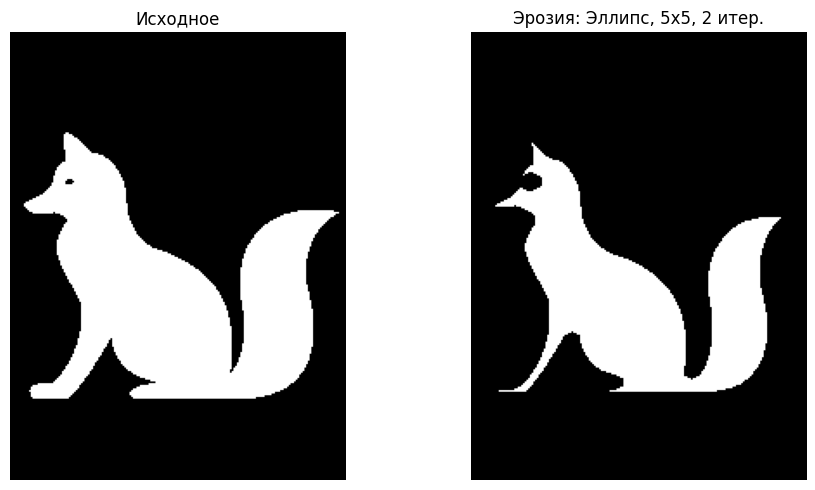

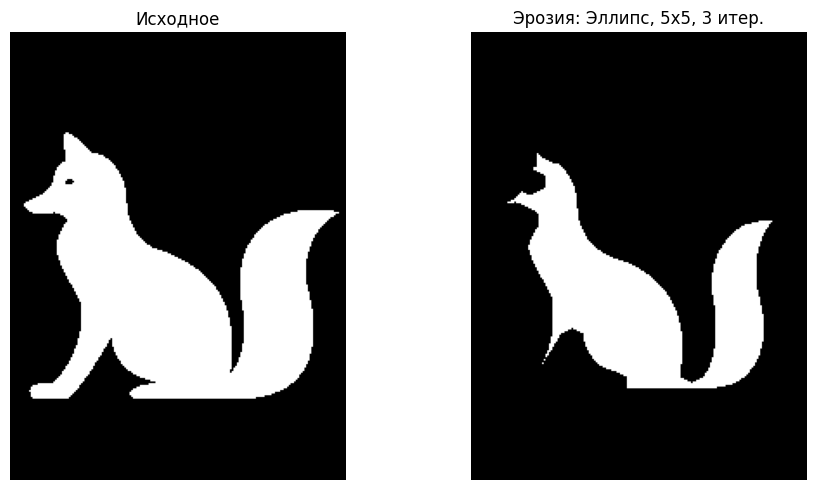

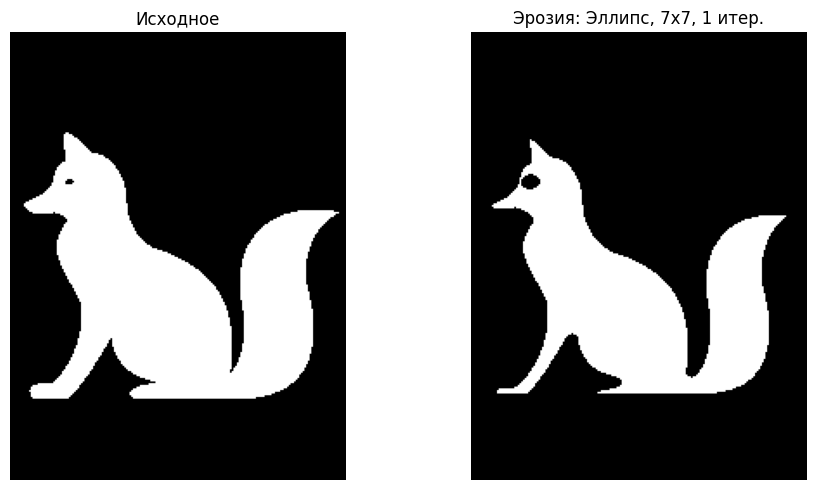

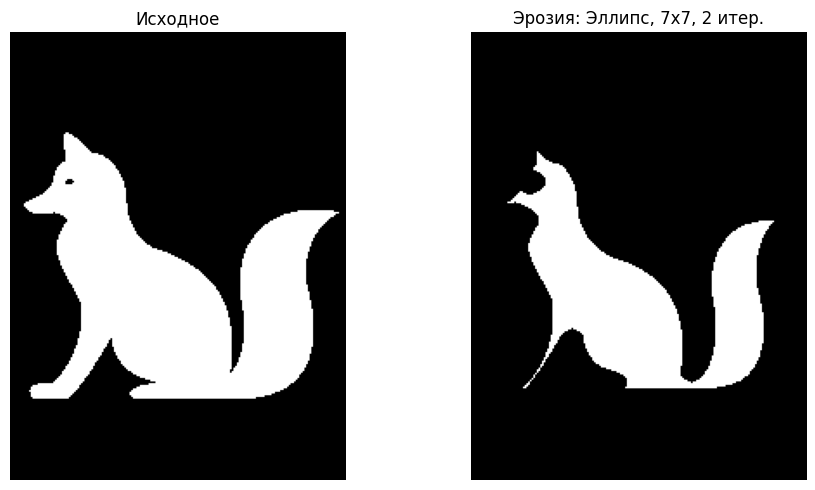

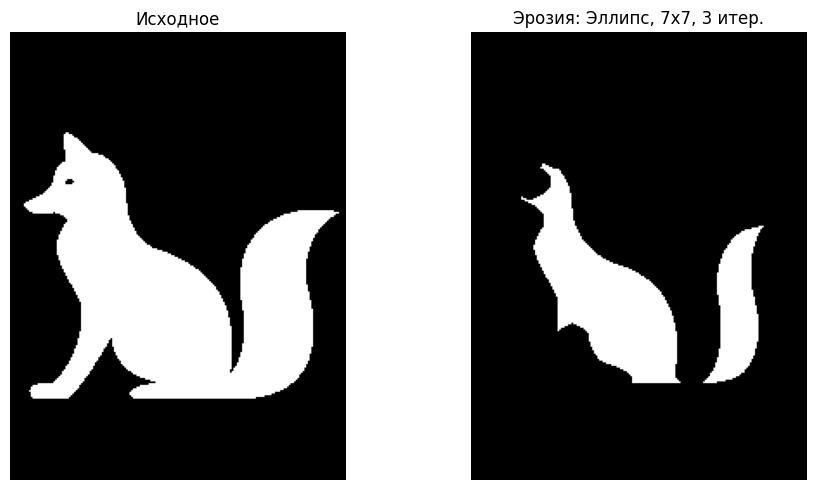

In [25]:
for se in se_types:
    for ksize in kernel_sizes:
        for it in iterations_list:
            result = apply_morphology(img_bin, 'erode', se, ksize, it)

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(img_bin, cmap='gray')
            axes[0].set_title('Исходное')
            axes[0].axis('off')
            axes[1].imshow(result, cmap='gray')
            axes[1].set_title(f'Эрозия: {se_names[se]}, {ksize}x{ksize}, {it} итер.')
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()

- Мы научились загружать изображение, бинаризовать его, находить центроид и угол ориентации.
- Создали универсальную функцию для дилатации и эрозии с любым структурным элементом.
- Визуально сравнили влияние разных SE, размеров и числа итераций.


## Открытие и закрытие

**Определения открытия и закрытия**

Пусть $A$ – бинарное изображение (множество точек объекта), $B$ – структурный элемент (также множество).




- **Открытие (opening)**: последовательно примененные эрозия (уменьшение объекта), а затем дилатация (расширение).


$$
A \circ B = (A \ominus B) \oplus B
$$
где $\ominus$ – эрозия, $\oplus$ – дилатация.

Открытие сглаживает контуры, увеличивает узкие разрывы, ликвидирует тонкие выступы.


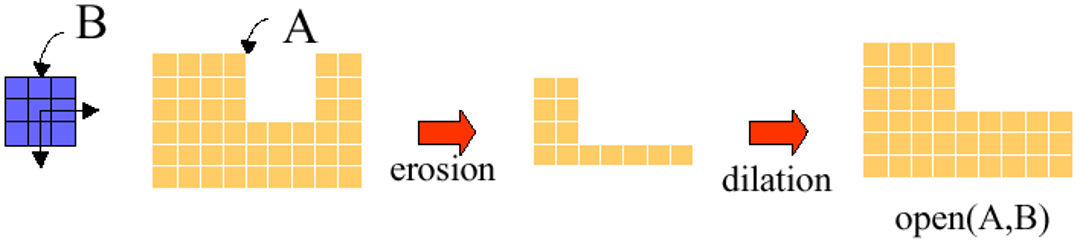

- **Закрытие (closing)**: представляет собой последовательное применение двух операций: сначала дилатации (расширения), а затем эрозии (сужения).

$$
A \bullet B = (A \oplus B) \ominus B
$$

Закрытие заполняет небольшие дыры и разрывы.



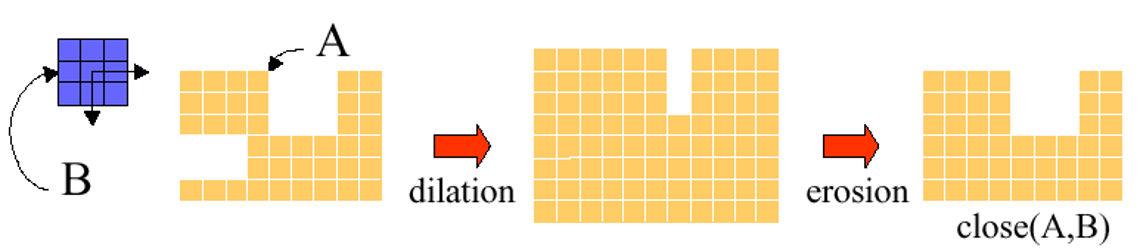

Рассмотрим пример

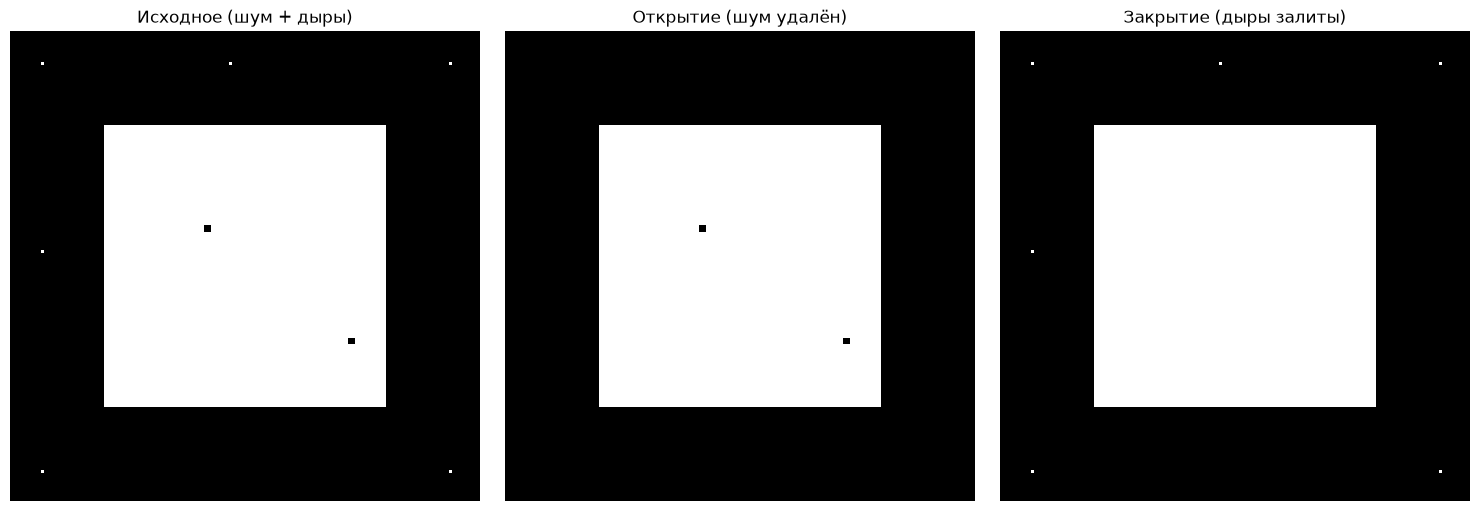

In [24]:
# Создаём чёрный фон (0) размером 150x150
img = np.zeros((150,150), dtype=np.uint8)

# Рисуем большой белый прямоугольник (объект)
img[30:120, 30:120] = 1

# Вырезаем две чёрные дыры (прямоугольные отверстия) внутри объекта
img[62:64, 62:64] = 0      # дыра 1
img[98:100, 108:110] = 0    # дыра 2

# Добавляем внешний шум — одиночные белые пиксели на фоне
img[10, 10] = 1
img[140, 140] = 1
img[10, 140] = 1
img[140, 10] = 1
img[70, 10] = 1
img[10, 70] = 1

# Структурный элемент (квадрат 3×3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Открытие – удаляет внешний шум
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# Закрытие – заливает дыры
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Исходное (шум + дыры)', 'Открытие (шум удалён)', 'Закрытие (дыры залиты)']

for ax, im, title in zip(axes, [img, opening, closing], titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Оба фильтра **идемпотентны**: повторное применение не меняет результат:

  $(A \circ B) \circ B = A \circ B$
  
  и
  
  $(A \bullet B) \bullet B = A \bullet B$,

  очевидно, что после выполнения первой операции повторное последовательное применение эрозии и дилатации (либо дилатации и эрозии) с одним и тем же структурным элементом, вернет объект к тому же состоянию.

Проверим идемпотентность открытия

In [25]:
# 1. Создаём изображение
#    - основной объект (прямоугольник)
#    - мелкие выступы и изолированные точки (шум)
np.random.seed(42)
img_open = np.zeros((150, 150), dtype=np.uint8)
# Основной объект
img_open[40:110, 40:110] = 1
# Добавляем выступы
for _ in range(12):
    x, y = np.random.randint(35, 115, 2)
    w, h = np.random.randint(3, 8, 2)
    img_open[y:y+h, x:x+w] = 1
# Добавляем изолированные шумовые точки
noise = np.random.rand(150, 150) < 0.02
img_open[noise] = 1

# 2. Структурный элемент (квадрат 5x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 3. Промежуточные шаги для открытия
eroded = cv2.erode(img_open, kernel, iterations=1)               # эрозия
opened = cv2.dilate(eroded, kernel, iterations=1)               # дилатация, получаем открытие
eroded_of_opened = cv2.erode(opened, kernel, iterations=1)      # эрозия открытия
opened_twice = cv2.dilate(eroded_of_opened, kernel, iterations=1) # дилатация, получаем повторное открытие

# 4. Проверка идемпотентности
print("Открытие: идентичность после повторного применения?",
      np.array_equal(opened, opened_twice))


Открытие: идентичность после повторного применения? True


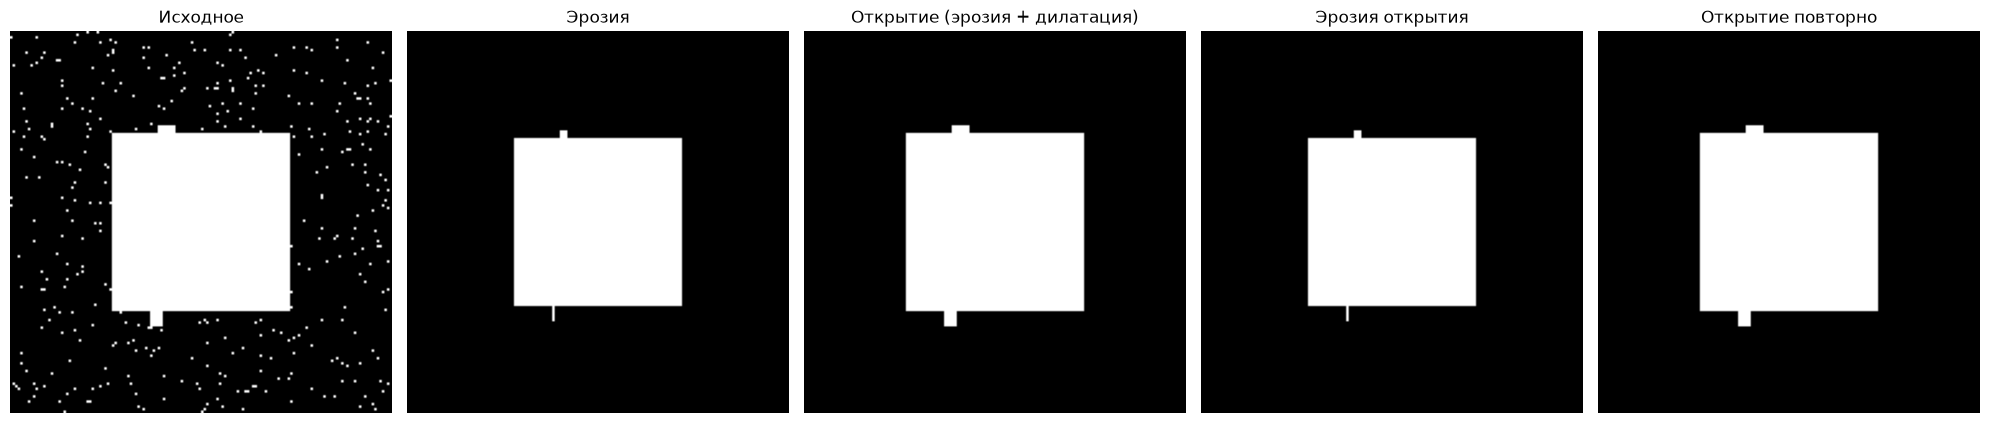

In [26]:
# 5. Визуализация
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
titles = ['Исходное', 'Эрозия', 'Открытие (эрозия + дилатация)',
          'Эрозия открытия', 'Открытие повторно']
images = [img_open, eroded, opened, eroded_of_opened, opened_twice]
for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

Проверим идемпотентность закрытия

In [27]:
# 1. Создаём изображение
#    - основной объект (прямоугольник)
#    - внутренние дыры и разрывы в контуре
np.random.seed(24)
img_close = np.zeros((150, 150), dtype=np.uint8)
# Основной объект
img_close[30:120, 30:120] = 1
# Добавляем дыры (маленькие вырезанные области)
for _ in range(15):
    x, y = np.random.randint(40, 110, 2)
    w, h = np.random.randint(3, 8, 2)
    img_close[y:y+h, x:x+w] = 0
# Добавляем разрывы в контуре (узкие вырезы)
for _ in range(8):
    x, y = np.random.randint(35, 115, 2)
    w, h = np.random.randint(2, 5, 2)
    img_close[y:y+h, x:x+w] = 0

# 2. Структурный элемент (квадрат 5x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 3. Промежуточные шаги для закрытия
dilated = cv2.dilate(img_close, kernel, iterations=1)            # дилатация
closed = cv2.erode(dilated, kernel, iterations=1)               # эрозия, получаем закрытие
dilated_of_closed = cv2.dilate(closed, kernel, iterations=1)    # дилатация закрытия
closed_twice = cv2.erode(dilated_of_closed, kernel, iterations=1) # эрозия, получаем повторное закрытие

# 4. Проверка идемпотентности
print("Закрытие: идентичность после повторного применения?",
      np.array_equal(closed, closed_twice))

Закрытие: идентичность после повторного применения? True


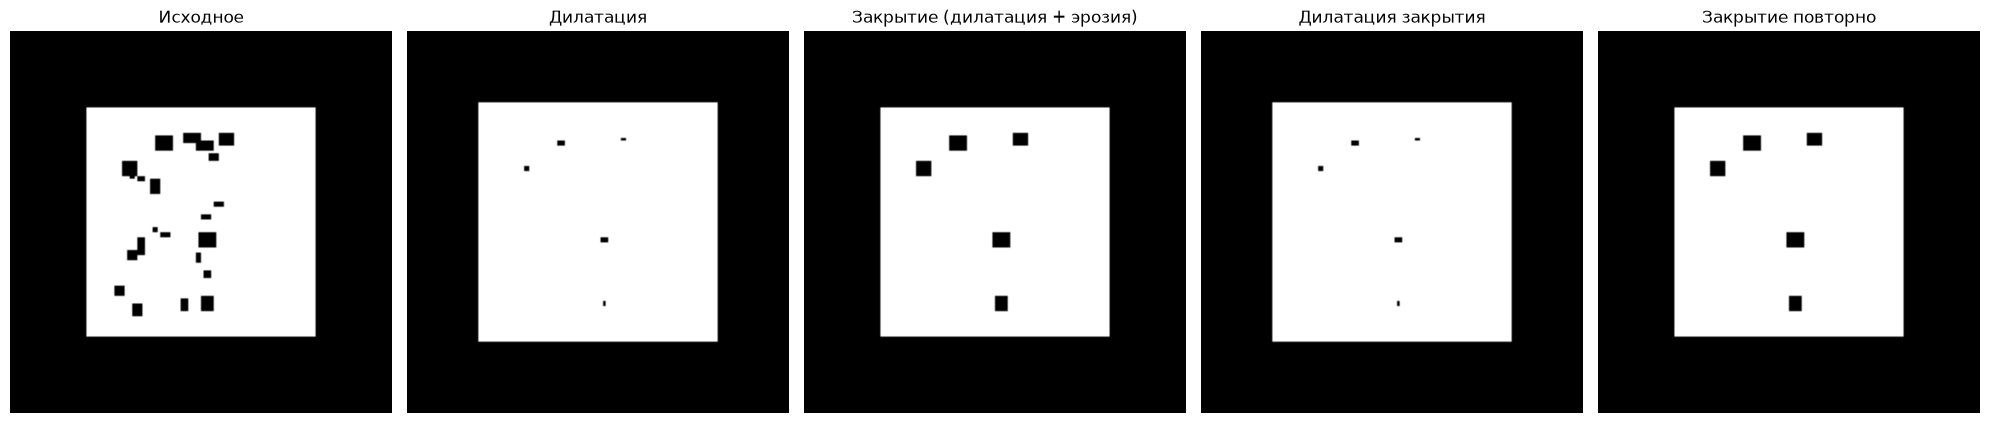

In [28]:
# 5. Визуализация
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
titles = ['Исходное', 'Дилатация', 'Закрытие (дилатация + эрозия)',
          'Дилатация закрытия', 'Закрытие повторно']
images = [img_close, dilated, closed, dilated_of_closed, closed_twice]
for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Выделение контура объекта

Если из исходного изображения объекта вычесть его эрозированную версию, то получится контур этого объекта $\text{boundary}(A) = A - (A \ominus B)$

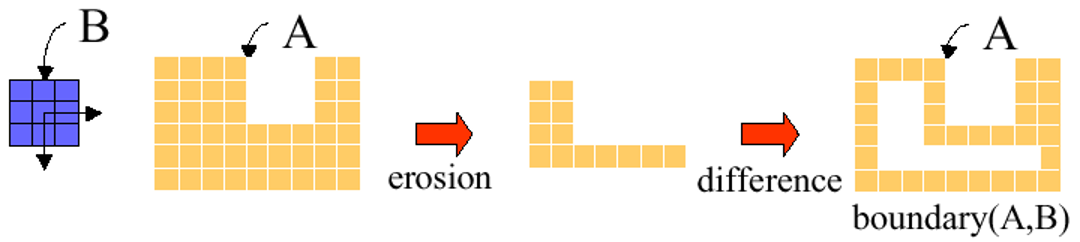

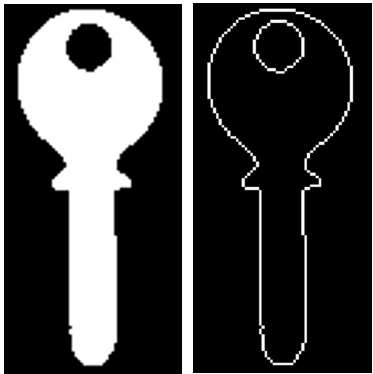

Визуализируем принцип вычисления границы

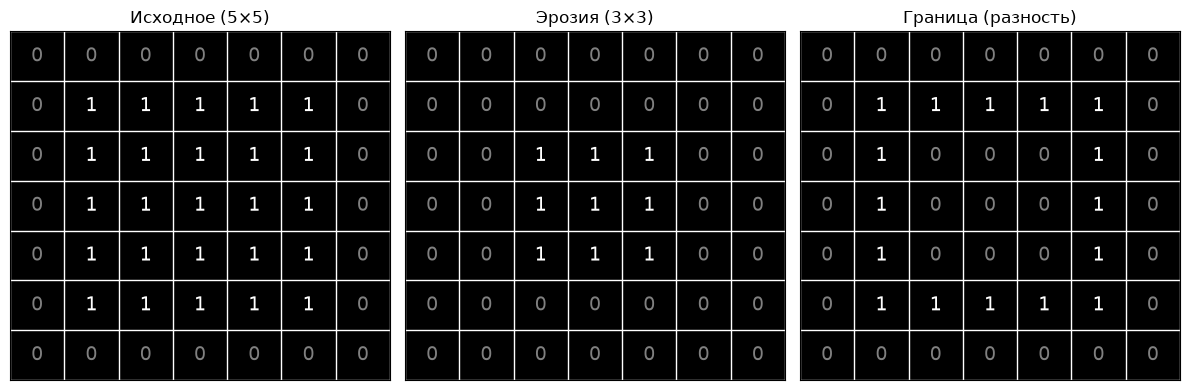

In [29]:
# Параметры
padding = 1          # количество нулей с каждой стороны
obj_size = 5         # размер исходного квадрата (5x5)
total_size = obj_size + 2 * padding

# Создаём изображение: фон из нулей, в центре квадрат 5x5 единиц
img = np.zeros((total_size, total_size), dtype=np.uint8)
img[padding:padding+obj_size, padding:padding+obj_size] = 1

# Структурный элемент (квадрат 3x3)
kernel = np.ones((3,3), dtype=np.uint8)

# Эрозия
eroded = cv2.erode(img, kernel, iterations=1)

# Граница = исходное – эрозия
boundary = img - eroded

# Функция отображения матрицы с цифрами
def show_matrix(ax, mat, title):
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('black')
    # Сетка
    for i in range(mat.shape[0] + 1):
        ax.axhline(i - 0.5, color='white', linewidth=1)
    for j in range(mat.shape[1] + 1):
        ax.axvline(j - 0.5, color='white', linewidth=1)
    # Вывод цифр
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if mat[i, j] == 1 else 'gray'
            ax.text(j, i, str(mat[i, j]), ha='center', va='center', fontsize=14, color=color)
    ax.set_xlim(-0.5, mat.shape[1] - 0.5)
    ax.set_ylim(mat.shape[0] - 0.5, -0.5)

# Визуализация трёх изображений
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_matrix(axes[0], img, 'Исходное (5×5)')
show_matrix(axes[1], eroded, 'Эрозия (3×3)')
show_matrix(axes[2], boundary, 'Граница (разность)')

plt.tight_layout()
plt.show()

Рассмотрим пример

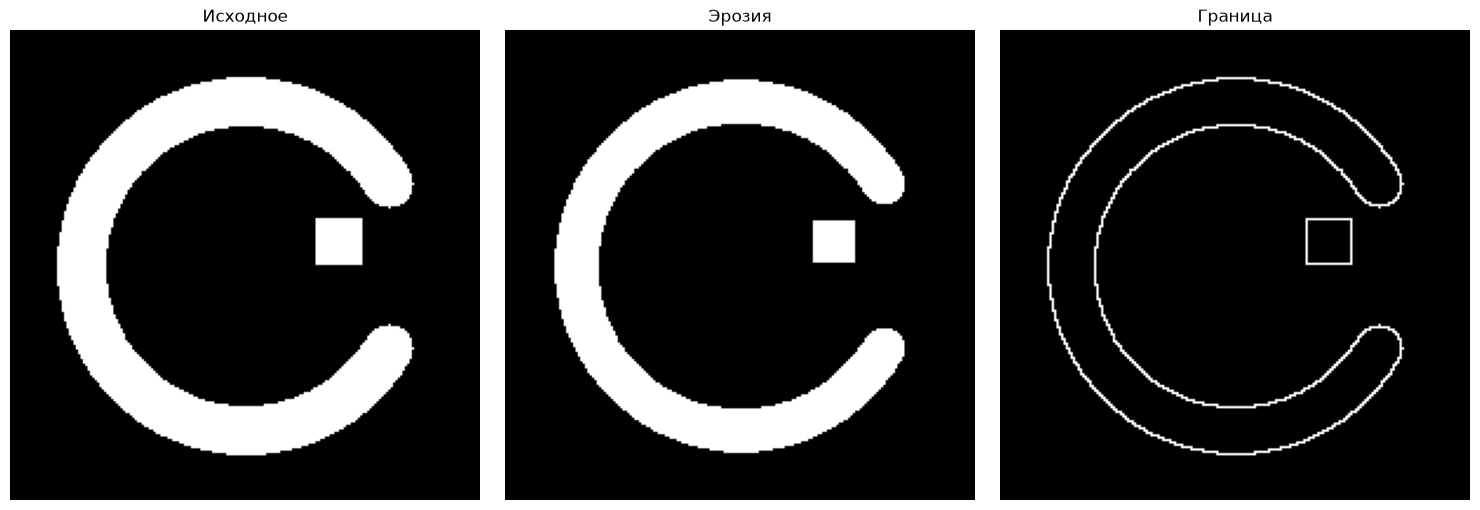

In [30]:
# Создаём бинарное изображение (объект – белый)
img = np.zeros((200,200), dtype=np.uint8)
cv2.ellipse(img, (100,100), (70,70), 0, 30, 330, 1, thickness=20)
# Добавляем маленький квадрат
img[80:100, 130:150] = 1

# Структурный элемент (квадрат 3×3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Эрозия
eroded = cv2.erode(img, kernel, iterations=1)

# Внутренняя граница: объект – эрозия
boundary_inner = cv2.subtract(img, eroded)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Исходное', 'Эрозия', 'Граница']

for ax, im, title in zip(axes, [img, eroded, boundary_inner], titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Рассмотрим еще пример

In [33]:
# ========== 1. Загрузка изображения с диска ==========
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

Saving Blobs.jpg to Blobs.jpg


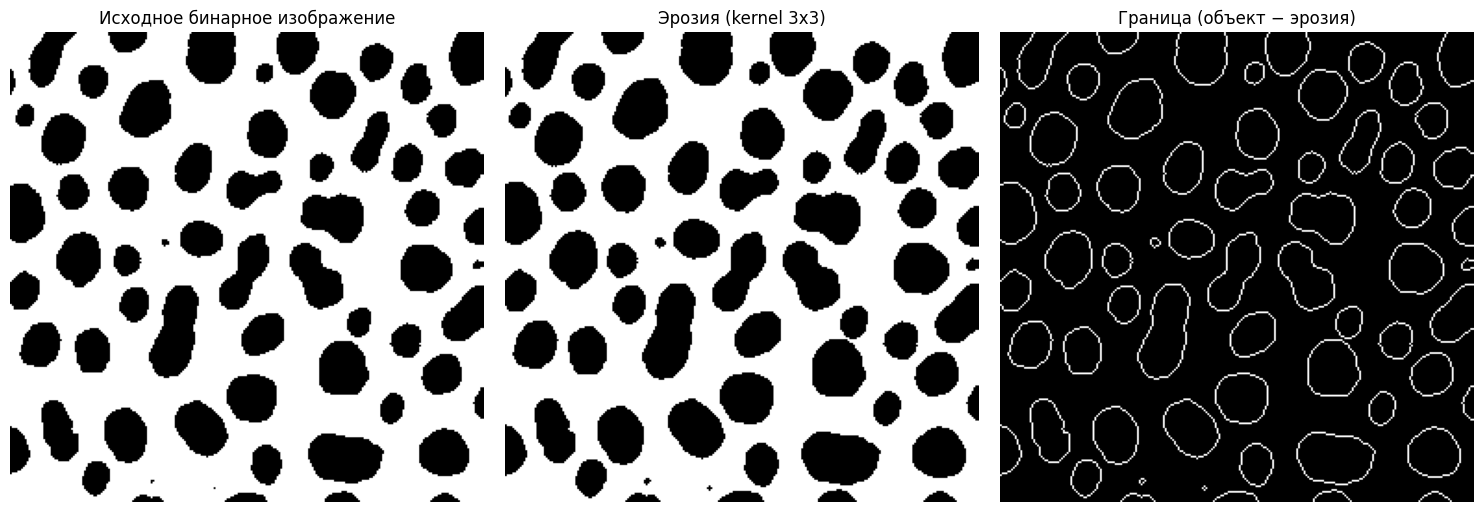

In [34]:
# ========== 2. Бинаризация ==========
_, binary = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY)   # объект = 1, фон = 0

# ========== 3. Морфологическая эрозия ==========
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))  # структурный элемент 3x3
eroded = cv2.erode(binary, kernel, iterations=1)

# ========== 4. Вычисление границы ==========
boundary = cv2.subtract(binary, eroded)   # объект - эрозия

# ========== 5. Визуализация ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Исходное бинарное изображение', 'Эрозия (kernel 3x3)', 'Граница (объект − эрозия)']
images = [binary, eroded, boundary]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Морфологический градиент



Морфологический градиент — это оператор, который также находит контуры и границы объектов. Он вычисляется как математическая разница между результатами расширения (дилатации) и сужения (эрозии) исходного изображения. Можно сказать, что он тоже выделяет границы объекта: $\text{grad}(A) = (A \oplus B) - (A \ominus B)$.

Рассмотрим пример

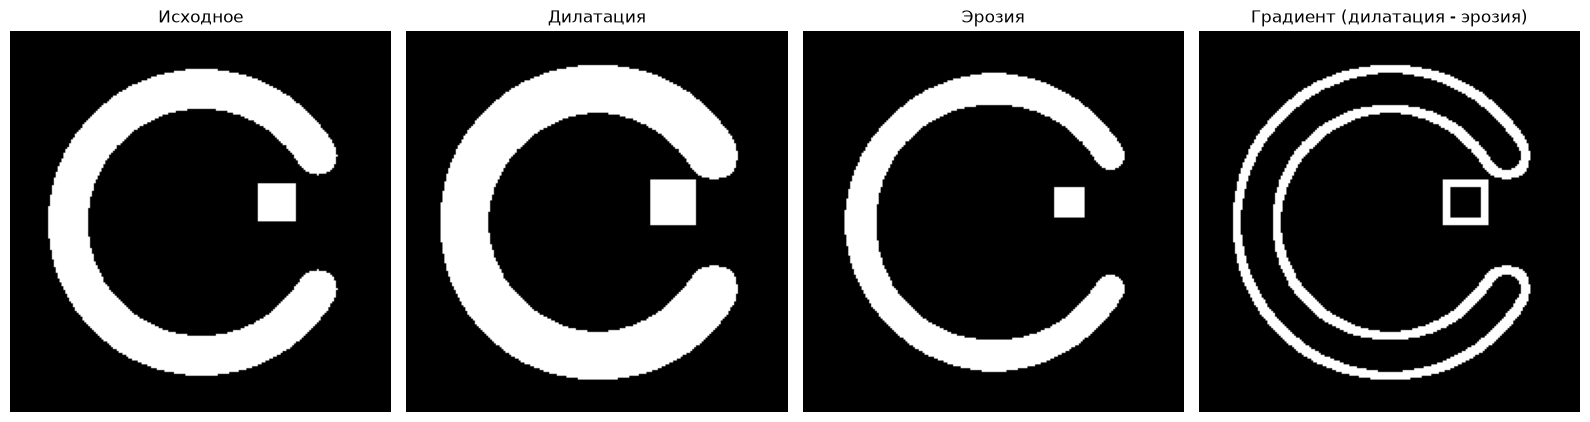

In [31]:
# Создаём бинарное изображение
img = np.zeros((200,200), dtype=np.uint8)

# Толстая дуга (подкова)
cv2.ellipse(img, (100,100), (70,70), 0, 30, 330, 1, thickness=20)

# Добавляем маленький квадрат
img[80:100, 130:150] = 1

# Структурный элемент (квадрат 5x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

# Дилатация и эрозия
dilated = cv2.dilate(img, kernel, iterations=1)
eroded = cv2.erode(img, kernel, iterations=1)

# Морфологический градиент
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

# Визуализация
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = ['Исходное', 'Дилатация', 'Эрозия', 'Градиент (дилатация - эрозия)']

for ax, im, title in zip(axes, [img, dilated, eroded, gradient], titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Еще один пример использования морфологического градиента для встроенного в библиотеку skimage изображения

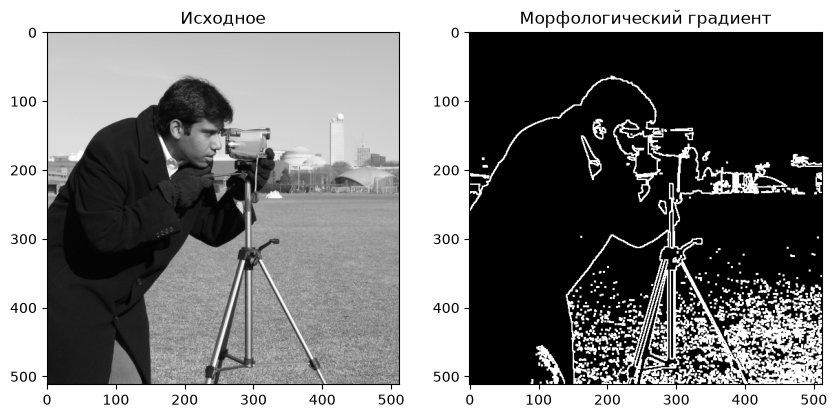

In [32]:
img_color = data.camera()
img_bin = img_color > 128
kernel = np.ones((3,3), np.uint8)
grad_morph = cv2.morphologyEx(img_bin.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img_color, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(grad_morph, cmap='gray'); axes[1].set_title('Морфологический градиент')
plt.show()

## Скелетизация (медиальная ось)

Скелет (медиальная ось) — это множество точек, равноудалённых от границ объекта. Алгоритм утончения (thinning) последовательно удаляет граничные пиксели, не нарушая связность.

**Свойства скелета:**

- Сохраняет топологию (количество отверстий и связность).

- Инвариантен к повороту и масштабу (при определённых условиях).

- Используется для распознавания форм, анализа и сжатия изображений.


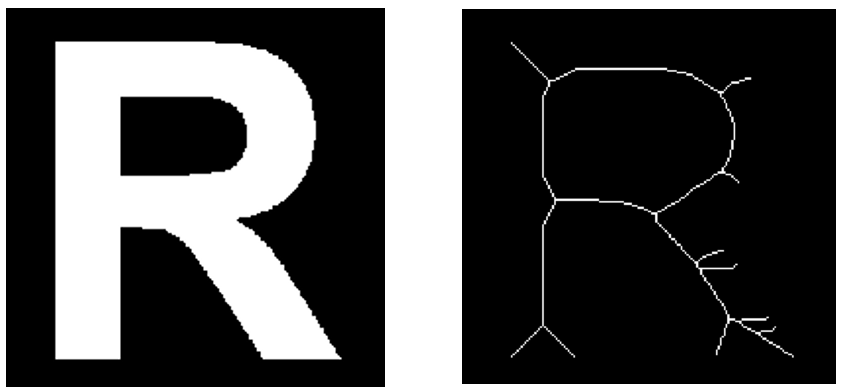

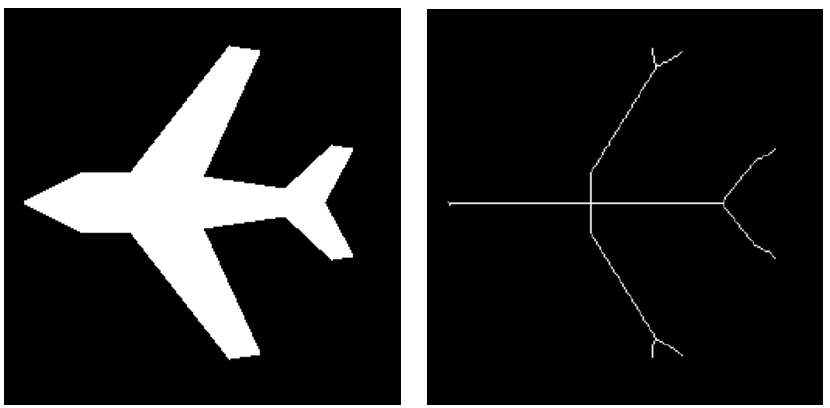

### Алгоритм Чжан-Суэня для скелетизации

Одним из наиболее известных итеративных алгоритмов скелетизации является **алгоритм Чжан-Суэня** (1984 г.).

Каждая итерация алгоритма состоит из двух подпроходов (субциклов), в которых проверяются условия удаления для каждого граничного пикселя (со значением 1, но имеющим хотя бы одного соседа со значением 0 - т.е. принадлежащего к фону). Пиксель удаляется (приравнивается к 0), если выполняются определённые условия, основанные на значениях его 8 соседей (окрестность 3х3).

#### Определение окрестности

Рассмотрим пиксель *P1* и его 8 соседей:

| P9 | P2 | P3 |
|----|----|----|
| P8 | *P1* | P4 |
| P7 | P6 | P5 |

#### Условия для первого подпрохода

Пиксель *P1* удаляется, если выполняются **все** следующие условия:

1. **2 ≤ B(P1) ≤ 6**,  
   где B(P1) – количество ненулевых соседей: B = P2+P3+...+P9.

2. **A(P1) = 1**,  
   где A(P1) – количество переходов от 0 к 1 при обходе соседей по часовой стрелке (P2→P3→...→P9→P2).

3. **P2·P4·P8 = 0** (хотя бы один из этих трёх соседей равен 0).

4. **P2·P4·P6 = 0** (хотя бы один из этих трёх соседей равен 0).

#### Условия для второго подпрохода

Условия 1 и 2 те же. Условия 3 и 4 заменяются на:

3'. **P2·P4·P6 = 0**  
4'. **P2·P8·P6 = 0**

### Особенности

- Алгоритм применяется **только к граничным пикселям** (имеющим хотя бы одного соседа со значением 0).
- Процесс повторяется итеративно, пока удаляются пиксели.
- Результат – «скелет» толщиной в 1 пиксель, сохраняющий топологию объекта (количество связных компонент и отверстий).


Ручная реализация алгоритма Чжан-Суэня на Python с использованием NumPy.

In [33]:
def zhang_suen_thinning(binary_image, max_iterations=None):
    """Возвращает скелет (uint8, 0 или 1)."""
    img = binary_image.copy().astype(np.uint8)
    h, w = img.shape
    # Добавляем рамку для удобства
    padded = np.pad(img, pad_width=1, mode='constant', constant_values=0)
    changed = True
    iteration = 0
    while changed and (max_iterations is None or iteration < max_iterations):
        changed = False
        iteration += 1

        # Первый подпроход
        markers1 = np.zeros_like(img, dtype=bool)
        for i in range(1, h+1):
            for j in range(1, w+1):
                if padded[i, j] == 0:
                    continue
                # Окрестность
                P2 = padded[i-1, j]
                P3 = padded[i-1, j+1]
                P4 = padded[i, j+1]
                P5 = padded[i+1, j+1]
                P6 = padded[i+1, j]
                P7 = padded[i+1, j-1]
                P8 = padded[i, j-1]
                P9 = padded[i-1, j-1]
                # B(P1)
                B = P2 + P3 + P4 + P5 + P6 + P7 + P8 + P9
                if not (2 <= B <= 6):
                    continue
                # A(P1)
                neighbours = [P2, P3, P4, P5, P6, P7, P8, P9, P2]
                A = 0
                for k in range(8):
                    if neighbours[k] == 0 and neighbours[k+1] == 1:
                        A += 1
                if A != 1:
                    continue
                # условия первого подпрохода
                if not (P2 * P4 * P8 == 0):
                    continue
                if not (P2 * P4 * P6 == 0):
                    continue
                markers1[i-1, j-1] = True
        # Применяем удаления
        for i in range(h):
            for j in range(w):
                if markers1[i, j]:
                    padded[i+1, j+1] = 0
                    img[i, j] = 0
                    changed = True

        # Второй подпроход
        markers2 = np.zeros_like(img, dtype=bool)
        for i in range(1, h+1):
            for j in range(1, w+1):
                if padded[i, j] == 0:
                    continue
                P2 = padded[i-1, j]
                P3 = padded[i-1, j+1]
                P4 = padded[i, j+1]
                P5 = padded[i+1, j+1]
                P6 = padded[i+1, j]
                P7 = padded[i+1, j-1]
                P8 = padded[i, j-1]
                P9 = padded[i-1, j-1]
                B = P2 + P3 + P4 + P5 + P6 + P7 + P8 + P9
                if not (2 <= B <= 6):
                    continue
                neighbours = [P2, P3, P4, P5, P6, P7, P8, P9, P2]
                A = 0
                for k in range(8):
                    if neighbours[k] == 0 and neighbours[k+1] == 1:
                        A += 1
                if A != 1:
                    continue
                # условия второго подпрохода
                if not (P2 * P4 * P6 == 0):
                    continue
                if not (P2 * P8 * P6 == 0):
                    continue
                markers2[i-1, j-1] = True
        # Применяем удаления
        for i in range(h):
            for j in range(w):
                if markers2[i, j]:
                    padded[i+1, j+1] = 0
                    img[i, j] = 0
                    changed = True
    return img


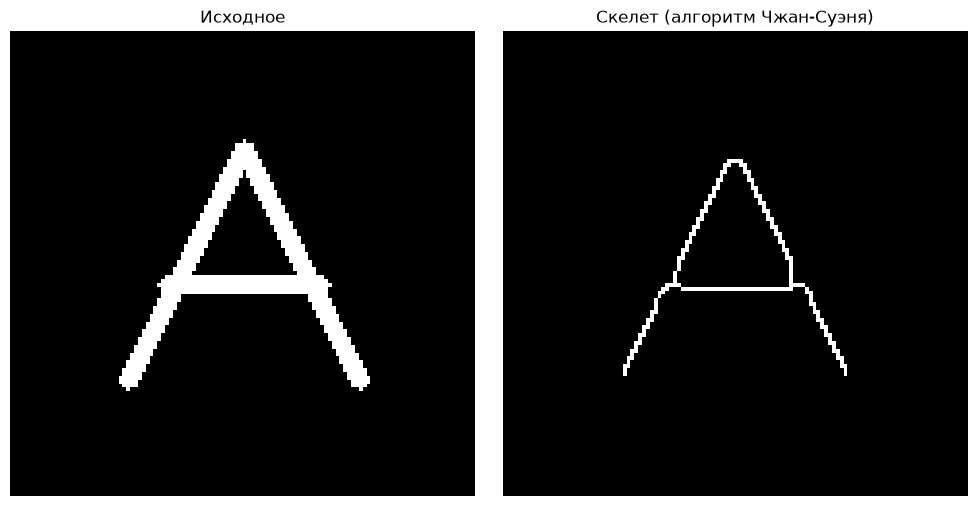

In [34]:
def create_letter_A(shape=(120, 120)):
    img = np.zeros(shape, dtype=np.uint8)
    center = shape[0] // 2, shape[1] // 2
    cv2.line(img, (center[1]-30, center[0]+30), (center[1], center[0]-30), 1, 3)
    cv2.line(img, (center[1]+30, center[0]+30), (center[1], center[0]-30), 1, 3)
    cv2.line(img, (center[1]-20, center[0]+5), (center[1]+20, center[0]+5), 1, 3)
    return img

test_img = create_letter_A((120, 120))
skeleton = zhang_suen_thinning(test_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Исходное')
axes[0].axis('off')
axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title('Скелет (алгоритм Чжан-Суэня)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Сравнение с встроенной функцией `skeletonize` из `skimage`

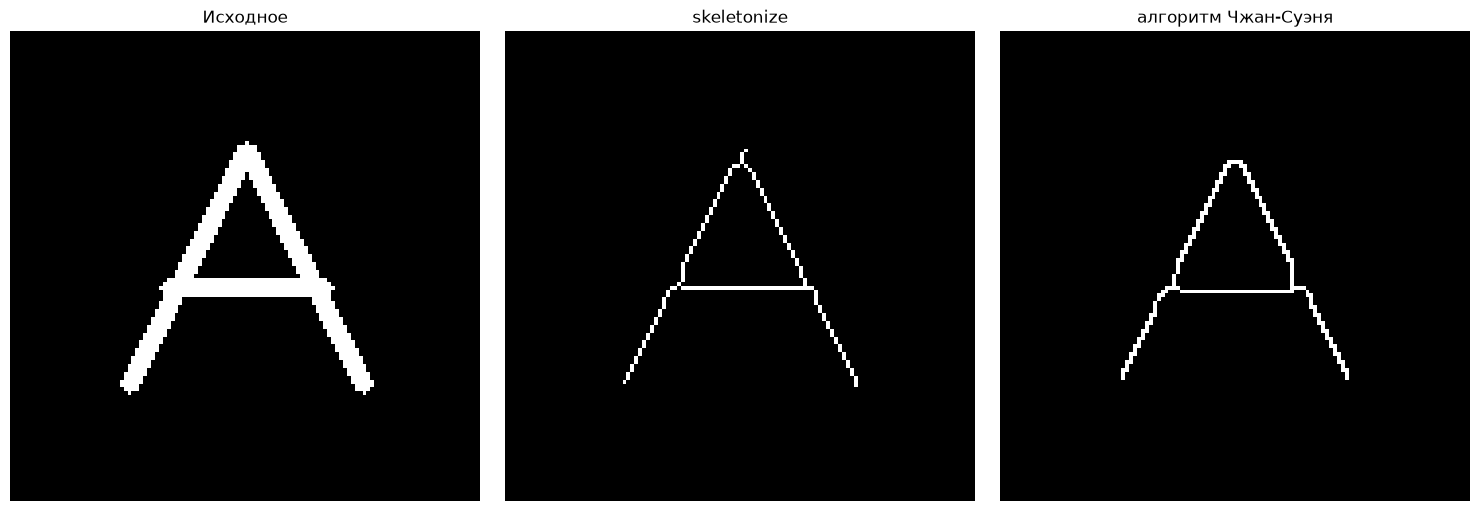

In [37]:
from skimage.morphology import skeletonize

# Используем ту же форму для сравнения
test_img = create_letter_A((120, 120))
skel_builtin = skeletonize(test_img)
skel_zhang = zhang_suen_thinning(test_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Исходное')
axes[0].axis('off')
axes[1].imshow(skel_builtin, cmap='gray')
axes[1].set_title('skeletonize')
axes[1].axis('off')
axes[2].imshow(skel_zhang, cmap='gray')
axes[2].set_title('алгоритм Чжан-Суэня')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### Демонстрация (бинарные пятна)

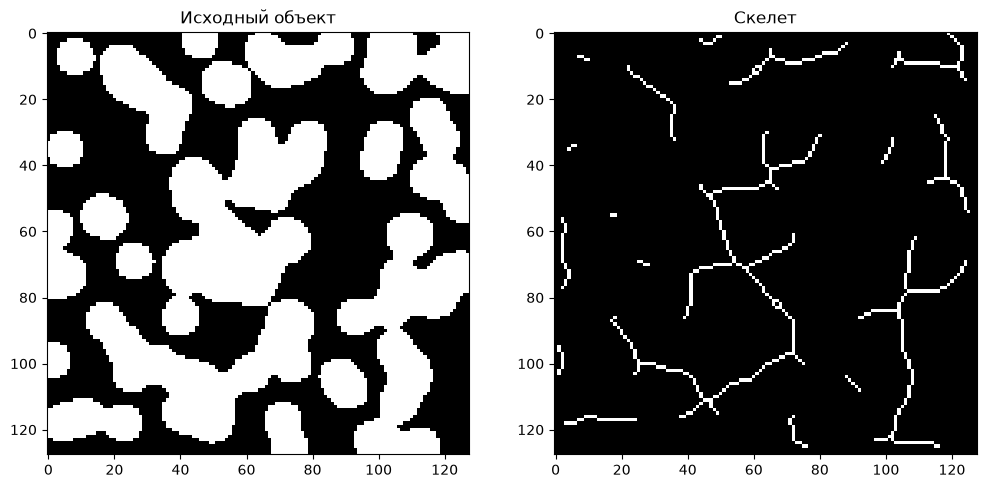

In [38]:
# Используем skimage.morphology.skeletonize
blob = data.binary_blobs(length=128, blob_size_fraction=0.1, n_dim=2)
skeleton = skeletonize(blob)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(blob, cmap='gray'); axes[0].set_title('Исходный объект')
axes[1].imshow(skeleton, cmap='gray'); axes[1].set_title('Скелет')
plt.show()

### Демонстрация (буквы)

In [41]:
# ========== 1. Загрузка изображения с диска ==========
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

Saving Буквы.bmp to Буквы.bmp


In [42]:
# ========== 2. Бинаризация ==========
# Приводим к бинарному формату: объект = 1, фон = 0
_, binary = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY)


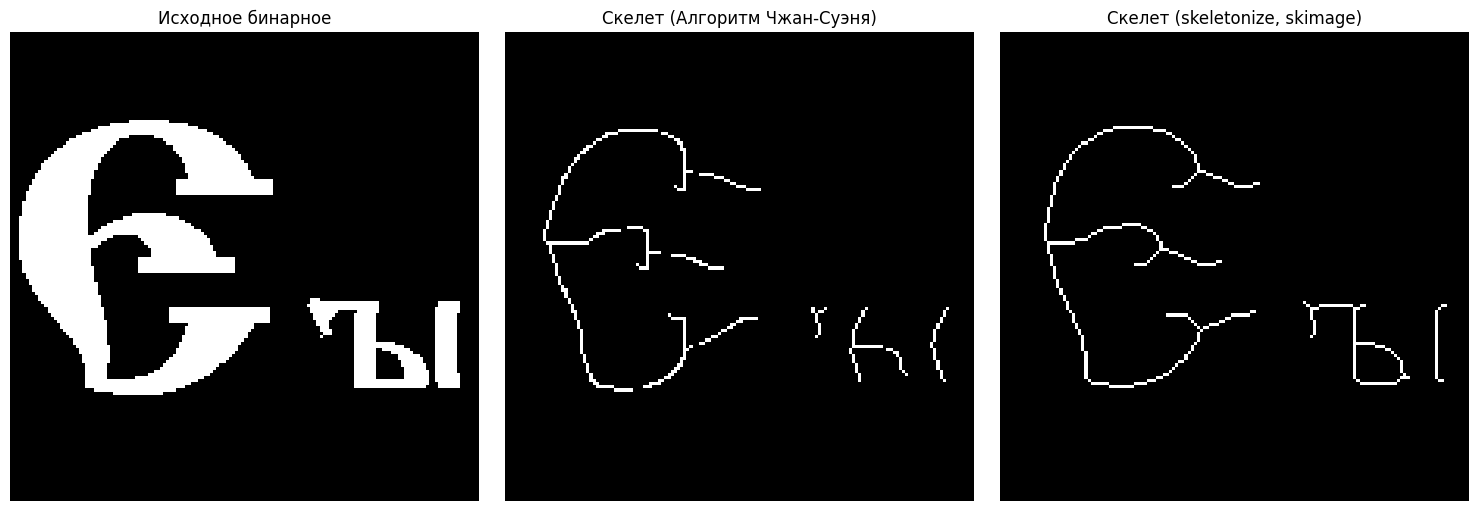

In [43]:
# ========== 3. Применяем алгоритм ==========
skeleton_zhang = zhang_suen_thinning(binary)

# Сравнение со встроенной функцией skeletonize из skimage
skeleton_lee = skeletonize(binary).astype(np.uint8)

# ========== 4. Визуализация ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Исходное бинарное')
axes[0].axis('off')
axes[1].imshow(skeleton_zhang, cmap='gray')
axes[1].set_title('Скелет (Алгоритм Чжан-Суэня)')
axes[1].axis('off')
axes[2].imshow(skeleton_lee, cmap='gray')
axes[2].set_title('Скелет (skeletonize, skimage)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Морфологическое подавление шума



Комбинация открытия и закрытия эффективно удаляет как светлый, так и тёмный шум.


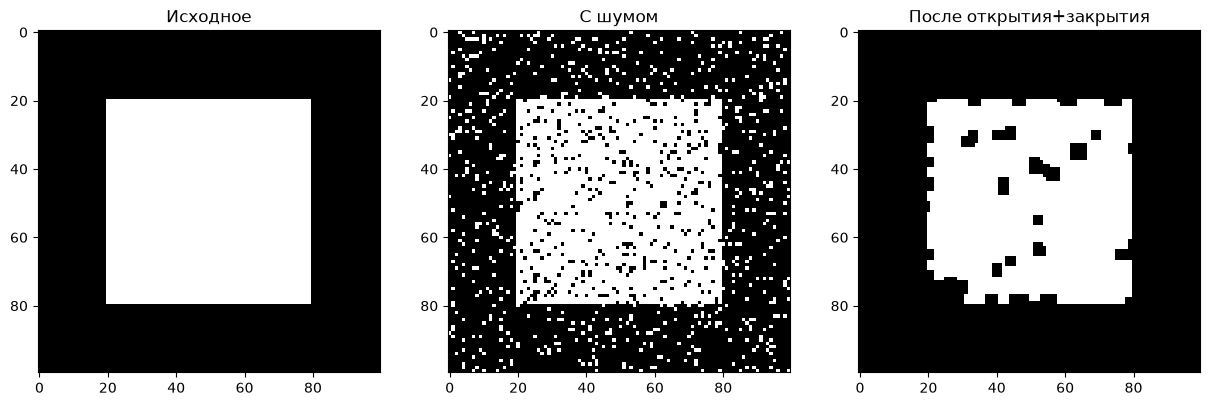

In [39]:
# Генерация шумного изображения
clean = np.zeros((100,100), np.uint8)
clean[20:80,20:80] = 1
noisy = clean.copy()

# Генерируем одну маску шума с вероятностью 10%
mask = np.random.rand(100,100) < 0.1
# Инвертируем значения пикселей только там, где маска True
noisy[mask] = 1 - noisy[mask]

kernel = np.ones((3,3), np.uint8)
denoised = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)
denoised = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(clean, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(noisy, cmap='gray'); axes[1].set_title('С шумом')
axes[2].imshow(denoised, cmap='gray'); axes[2].set_title('После открытия+закрытия')
plt.show()

## Фильтры White Top-Hat и Black Top-Hat

Эти морфологические операции предназначены для **выделения мелких деталей** на неоднородном фоне. Они основаны на разности между исходным изображением и его морфологическим открытием или закрытием.

### Определения

Пусть $A$ — исходное полутоновое изображение, $B$ — структурный элемент.

- **White Top-Hat** (светлый фильтр) — разность между исходным изображением и его открытием:
  $$
  WTH(A) = A - (A \circ B)
  $$
  где $A \circ B = (A \ominus B) \oplus B $ — морфологическое открытие.

- **Black Top-Hat** (тёмный фильтр) — разность между закрытием и исходным изображением:
  $$
  BTH(A) = (A \bullet B) - A
  $$
  где $A \bullet B = (A \oplus B) \ominus B$ — морфологическое закрытие.



### Геометрическая интерпретация

- **White Top-Hat** выделяет **яркие** детали (пики), которые меньше структурного элемента и не могут быть воспроизведены открытием. Открытие удаляет такие детали, а разность их восстанавливает. Результат — выявляются объекты ярче фона (локальные максимумы).

- **Black Top-Hat** выделяет **тёмные** детали (впадины), которые меньше структурного элемента. Закрытие заполняет их, а разность их выделяет. Результат — находятся объекты темнее фона (локальные минимумы).

### Применение

1. **Выравнивание неравномерного фона**  
   Белый (White Top-Hat) фильтр удаляет плавные градиенты фона, оставляя только мелкие яркие детали (например, клетки на микроскопической фотографии).

2. **Сегментация мелких объектов**  
   Используется в задачах анализа медицинских изображений (подсчёт кровяных телец, детекция микрокапель).

3. **Улучшение контраста**  
   Сложение/вычитание результатов Top-Hat фильтров позволяет повысить локальный контраст.

4. **Извлечение текстурных признаков**  
   В комбинации с разными размерами структурных элементов даёт информацию о размерах ярких/тёмных структур.





### Свойства


- **Неидемпотентность** — повторное применение может дать другой результат (в отличие от открытия/закрытия).
- **Чувствительность к размеру SE** — мелкие структурные элементы выделяют более тонкие детали, крупные — более грубые.
- **Инвариантность к монотонным преобразованиям** яркости (кроме сдвига/масштаба).

Рассмотрим пример

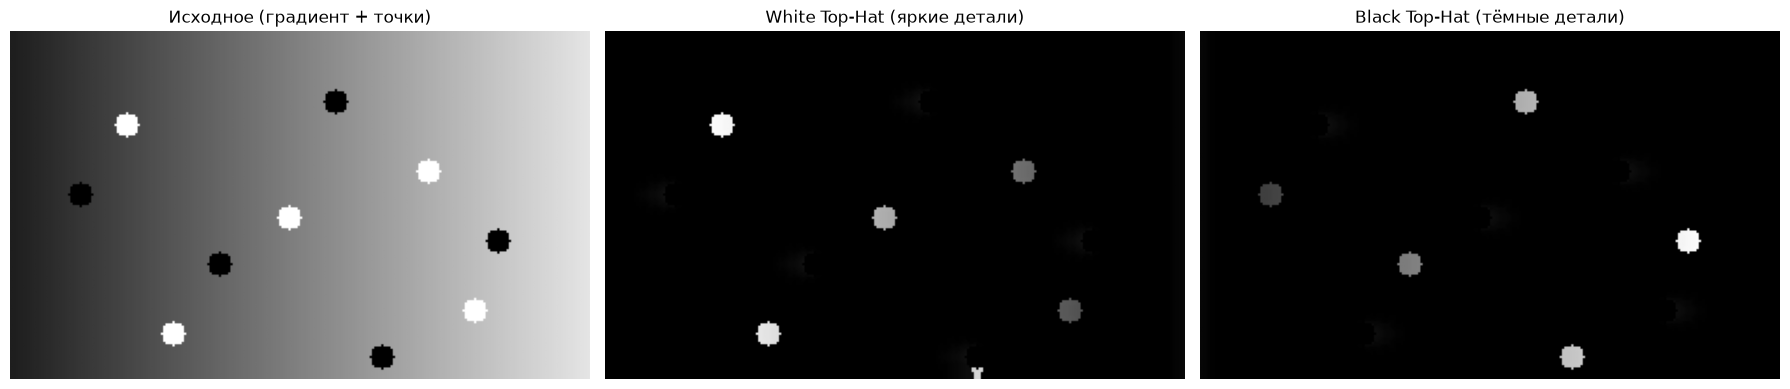

In [40]:
# 1. Создаём тестовое изображение с неравномерным фоном и мелкими точками
img = np.zeros((150, 250), dtype=np.uint8)
# Горизонтальный градиент (фон)
for i in range(250):
    img[:, i] = int(200 * i / 250) + 30  # значения от 30 до 230

# Добавляем яркие (white) и тёмные (black) точки
# Яркие точки (255)
white_spots = [(50, 40), (120, 80), (180, 60), (200, 120), (70, 130)]
# Тёмные точки (0)
black_spots = [(90, 100), (140, 30), (210, 90), (30, 70), (160, 140)]

for x, y in white_spots:
    cv2.circle(img, (x, y), 5, 255, -1)
for x, y in black_spots:
    cv2.circle(img, (x, y), 5, 0, -1)

# 2. Применяем White Top-Hat и Black Top-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
white_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
black_tophat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

# 3. Визуализация изображений
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Исходное (градиент + точки)',
          'White Top-Hat (яркие детали)',
          'Black Top-Hat (тёмные детали)']
images = [img, white_tophat, black_tophat]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

1) Исходное изображение — плавный горизонтальный градиент (неравномерный фон) с добавленными яркими (255) и тёмными (0) точками.

2) White Top-Hat — выделяет только яркие точки (пики), полностью удаляя градиент фона.

3) Black Top-Hat — выделяет только тёмные точки (впадины), фон также удалён.

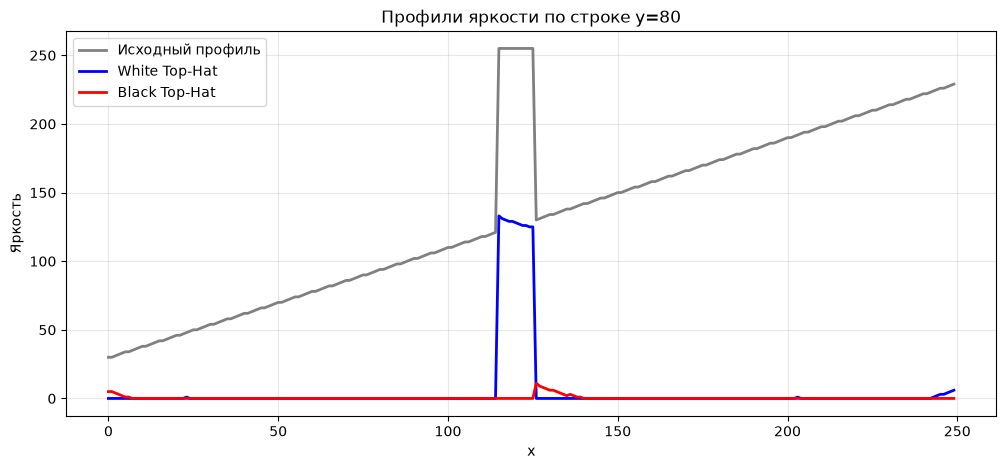

In [41]:
# 4. Построение одномерных профилей (горизонтальное сечение по строке y=80)
row = 80
y = row
x_axis = np.arange(250)

# Исходный профиль
original_profile = img[y, :]
white_profile = white_tophat[y, :]
black_profile = black_tophat[y, :]

plt.figure(figsize=(12, 5))
plt.plot(x_axis, original_profile, label='Исходный профиль', color='gray', linewidth=2)
plt.plot(x_axis, white_profile, label='White Top-Hat', color='blue', linewidth=2)
plt.plot(x_axis, black_profile, label='Black Top-Hat', color='red', linewidth=2)
plt.title(f'Профили яркости по строке y={y}')
plt.xlabel('x')
plt.ylabel('Яркость')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Профили яркости — на графике видно, что исходный фон линейно нарастает, White Top-Hat даёт пик (шляпу), что и объясняет название фильтров.

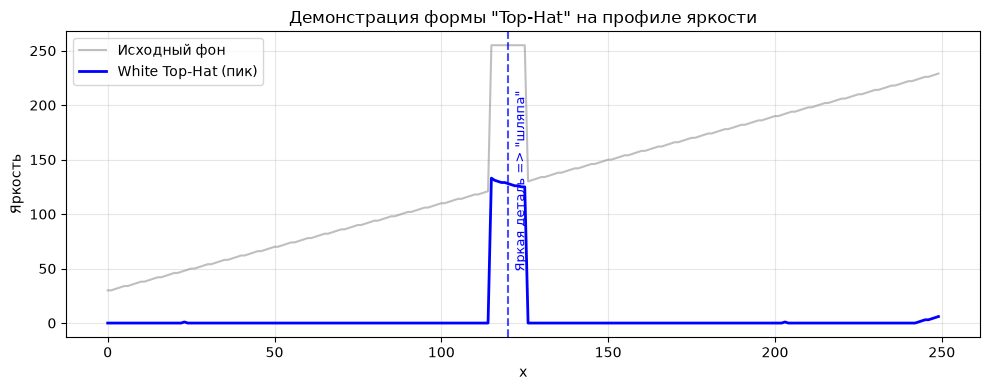

In [42]:
# 5. Отдельно построим "шляпоподобные" графики для пояснения названия
# Выбираем один яркий пик на позиции x = 120
bright_x = 120

plt.figure(figsize=(10, 4))
plt.plot(x_axis, original_profile, label='Исходный фон', color='gray', alpha=0.5)
plt.plot(x_axis, white_profile, label='White Top-Hat (пик)', color='blue', linewidth=2)
plt.axvline(bright_x, color='blue', linestyle='--', alpha=0.7)
plt.text(bright_x+2, 50, 'Яркая деталь => "шляпа"', rotation=90, fontsize=9, color='blue')
plt.title('Демонстрация формы "Top-Hat" на профиле яркости')
plt.xlabel('x')
plt.ylabel('Яркость')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

White Top-Hat и Black Top-Hat — эффективные инструменты для выделения локальных особенностей на неоднородном фоне. Они особенно полезны в предобработке изображений перед сегментацией, где требуется устранить плавные градиенты и извлечь мелкие объекты. Подбор размера структурного элемента зависит от характерного размера интересующих деталей.

## Морфологическая реконструкция

### 1. Основная идея морфологической реконструкции

Морфологическая реконструкция позволяет **восстановить объекты** на изображении, исходя из заданных маркеров (небольших областей внутри объектов), и **подавить все структуры**, которые не достижимы из этих маркеров. Это итеративный процесс, в котором маркеры «разрастаются» (дилатируются) с геодезическим ограничением – они не могут выходить за пределы исходного изображения $I$.

#### Математическое определение

Пусть:
- $I$ – исходное изображение (маска, ограничивающая область),
- $M$ – маркерное изображение ($ M \subseteq I $ – маркерное изображение $M$ является подмножеством исходного изображения
$I$ по значениям пикселей),
- $B$ – структурный элемент (обычно квадрат или крест).

**Геодезическая дилатация** размера 1:
$$
\delta_B^{(1)}(M) = (M \oplus B) \cap I
$$
то есть сначала выполняется обычная дилатация маркера, затем пересечение с исходным изображением – это не позволяет «вылезти» за пределы изображения $I$.

**Геодезическая дилатация** размера $n$:
$$
\delta_B^{(n)}(M) = \delta_B^{(1)}\big(\delta_B^{(n-1)}(M)\big)
$$
– повторное применение.

**Морфологическая реконструкция**:
$$
R_I(M) = \lim_{n \to \infty} \delta_B^{(n)}(M)
$$
На практике итерации продолжаются до тех пор, пока изображение не перестанет меняться (достигается неподвижная точка).

#### Геометрическая интерпретация

Представьте, что $I$ – бинарное изображение, содержащее несколько несвязанных объектов (например, круги). Маркеры $M$ – это маленькие области (например, одна точка или небольшой круг) внутри каждого объекта. Процесс реконструкции тогда выглядит так:
1. Маркеры расширяются за счет дилатации, но не могут выйти за пределы соответствующего объекта.
2. Если маркер находится внутри объекта, в итоге он заполнит весь этот объект.
3. Если маркер лежит на фоне или на шумовом пикселе, его дилатация быстро ограничится фоном и не даст большого региона.

В результате реконструкция выделяет **только те связные компоненты**, внутри которых были маркеры. Все остальные структуры (включая шум) исчезают.

#### Свойства

1. **Идемпотентность**: $R_I(R_I(M)) = R_I(M)$.
2. **Монотонность по маркеру**: чем больше маркер, тем больше результат.
3. **Удаление не маркированных структур** – всё, что не достижимо из маркеров, исчезает.
4. **Сохранение границ** – объекты восстанавливаются точно в своих исходных границах (не расширяются и не сжимаются).

#### Применение

- **Очистка бинарных изображений** от шума без потери крупных объектов.
- **Выделение объектов по внутренним точкам** (например, ядра клеток на микрофотографиях), для разделения слипшихся объектов и для морфологического сглаживания.

### 2. Морфологическая реконструкция для выделения объектов по внутренним маркерам



Рассмотрим изображение с несколькими объектами, частично перекрытыми шумом. Зададим маркеры — небольшие области внутри каждого объекта, и выполним реконструкцию.


In [ ]:
from skimage import data, morphology, filters, segmentation, measure
from skimage.morphology import reconstruction, disk, square
from skimage.segmentation import watershed
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

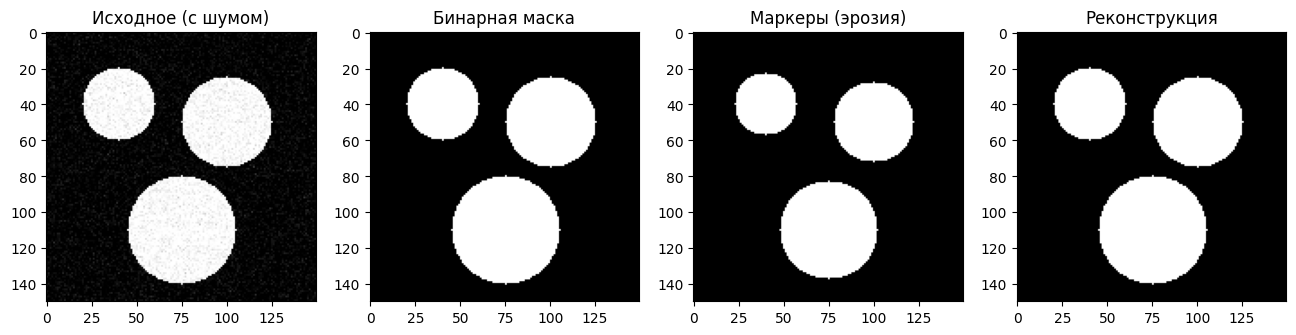

Количество объектов в маске: 3
Количество объектов после реконструкции: 3


In [49]:
# Создаём синтетическое изображение: три круга разных размеров
img = np.zeros((150,150), dtype=np.uint8)
cv2.circle(img, (40,40), 20, 255, -1)
cv2.circle(img, (100,50), 25, 255, -1)
cv2.circle(img, (75,110), 30, 255, -1)
# Добавляем шум
img = img.astype(float)
img += np.random.normal(0, 15, img.shape)
img = np.clip(img, 0, 255).astype(np.uint8)

# Бинаризация порогом Otsu
binary = filters.threshold_otsu(img)
mask = (img > binary).astype(np.uint8)

# Создаём маркеры: эрозия для получения внутренних ядер
marker = morphology.erosion(mask, morphology.disk(3))

# Морфологическая реконструкция
reconstructed = morphology.reconstruction(marker, mask, method='dilation')

# Визуализация
fig, axes = plt.subplots(1,4, figsize=(16,5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Исходное (с шумом)')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Бинарная маска')
axes[2].imshow(marker, cmap='gray'); axes[2].set_title('Маркеры (эрозия)')
axes[3].imshow(reconstructed, cmap='gray'); axes[3].set_title('Реконструкция')
plt.show()

# Подсчёт объектов (вычитаем 1, т.к. фон имеет метку 0)
print(f"Количество объектов в маске: {len(np.unique(measure.label(mask, connectivity=2))) - 1}")
print(f"Количество объектов после реконструкции: {len(np.unique(measure.label(reconstructed, connectivity=2))) - 1}")

**Интерпретация:**  
- **Бинарное изображение** с тремя кругами + много шумовых пикселей.
- Маркеры – это уменьшенные версии объектов (эрозия) каждого круга (небольшие «ядрышки» внутри).
- Реконструкция восстанавливает только три круга, шум удаляется. Реконструкция позволяет избавиться от мелких артефактов, сохраняя крупные объекты.
- Подсчёт объектов после реконструкции даёт правильное число (3), а без реконструкции – много ложных объектов.

Рассмотрим пример работы алгоритма с загруженным изображением

In [50]:
# ========== 1. Определение изображения  ==========
img = cv2.imread('Blobs.jpg', cv2.IMREAD_GRAYSCALE)

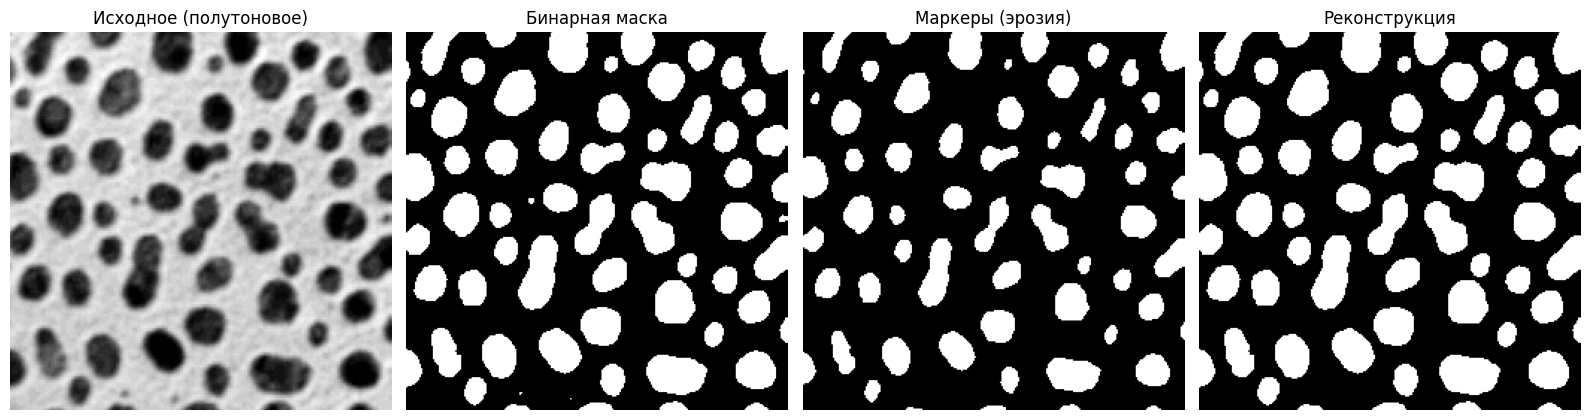

Количество объектов в исходной бинарной маске: 64
Количество объектов после реконструкции: 60


In [51]:
# ========== 2. Бинаризация и выделение маркеров ==========
# Бинаризация методом Оцу
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

binary = 255 - binary # инверсия цвета

# Маркеры: эрозия бинарного изображения (внутренние области объектов)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
markers = cv2.erode(binary, kernel, iterations=1)

# ========== 3. Морфологическая реконструкция (геодезическая дилатация) ==========
# Используем встроенную функцию из skimage (реализует R_I(M))
reconstructed = reconstruction(markers, binary, method='dilation')

# ========== 4. Визуализация ==========
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = ['Исходное (полутоновое)', 'Бинарная маска', 'Маркеры (эрозия)', 'Реконструкция']
images = [img, binary, markers, reconstructed]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Подсчёт объектов до и после реконструкции
from skimage import measure
labels_original = measure.label(binary, connectivity=2)
labels_recon = measure.label(reconstructed, connectivity=2)
print(f"Количество объектов в исходной бинарной маске: {len(np.unique(labels_original))-1}")
print(f"Количество объектов после реконструкции: {len(np.unique(labels_recon))-1}")

## Практика: загрузка своего изображения с диска

In [52]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img_user = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
_, img_bin = cv2.threshold(img_user, 127, 1, cv2.THRESH_BINARY)

def process_user(operation, se_shape, kernel_size, iterations):
    if se_shape == 'rect':
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    elif se_shape == 'cross':
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    else:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

    if operation == 'dilate':
        result = cv2.dilate(img_bin, kernel, iterations=iterations)
    elif operation == 'erode':
        result = cv2.erode(img_bin, kernel, iterations=iterations)
    elif operation == 'open':
        result = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel, iterations=iterations)
    else:
        result = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel, iterations=iterations)

    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img_bin, cmap='gray'); axes[0].set_title('Исходное')
    axes[1].imshow(result, cmap='gray'); axes[1].set_title(f'{operation} {se_shape} k={kernel_size} iter={iterations}')
    plt.show()

op_w = widgets.Dropdown(options=['dilate','erode','open','close'], value='dilate', description='Операция')
se_w = widgets.Dropdown(options=['rect','cross','ellipse'], value='rect', description='SE форма')
k_w = widgets.IntSlider(min=1, max=15, step=2, value=3, description='Размер SE')
i_w = widgets.IntSlider(min=1, max=5, value=1, description='Итерации')
ui2 = widgets.VBox([op_w, se_w, k_w, i_w])
out2 = widgets.interactive_output(process_user, {'operation':op_w, 'se_shape':se_w, 'kernel_size':k_w, 'iterations':i_w})
display(ui2, out2)

Saving binarization.bmp to binarization.bmp


Output()



## Итоги лекции

- **Дилатация и эрозия** – основа морфологии.
- **Открытие и закрытие** – мощные фильтры для шумоподавления и восстановления.
- **Морфологический градиент** – выделение контуров.
- **Скелетизация** – сжатие формы до линии.
- Комбинация операций позволяет решать сложные задачи сегментации.